<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/subin/%EC%88%98%EB%B9%88_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 데이터셋 압축 해제
import zipfile
import os

# CADICA zip
CADICA_dataset = "/content/drive/MyDrive/dataset_medical/CADICA.zip"

with zipfile.ZipFile("/content/drive/MyDrive/dataset_medical/CADICA.zip", "r") as zip_ref:
     zip_ref.extractall("./CADICA")
     print("CADICA 압축 해제 완료!")

# ADSD zip
ADSD_dataset = "/content/drive/MyDrive/dataset_medical/Stenosis detection.zip"

with zipfile.ZipFile("/content/drive/MyDrive/dataset_medical/Stenosis detection.zip", "r") as zip_ref:
  zip_ref.extractall("./ADSD")
  print("ADSD 압축 해제 완료!")

CADICA 압축 해제 완료!
ADSD 압축 해제 완료!


In [ ]:
# @title PyTorch 시드 및 디바이스 설정
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, roc_auc_score

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 현재 디바이스: {device}")

✅ 현재 디바이스: cuda


In [ ]:
# @title 기존 ADSD 이미지와 환자 split 연결
import glob
import os

# ADSD 전체 이미지 파일 경로 긁어오기
img_paths = glob.glob('./ADSD/dataset/*.bmp')
print(f"총 발견된 ADSD 이미지 개수: {len(img_paths)}개")

# 이미지 경로를 기반으로 데이터프레임 생성
adsd_img_df = pd.DataFrame({'file_path': img_paths})

# 파일명에서 patient_id 추출하는 함수 정의
# 예: './ADSD/dataset/14_022_7_0042.bmp' -> '14_022'
def extract_patient_id(path):
    filename = os.path.basename(path) # '14_022_7_0042.bmp'
    parts = filename.split('_')       # ['14', '022', '7', '0042.bmp']
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}" # '14_022'
    return None

adsd_img_df['patient_id'] = adsd_img_df['file_path'].apply(extract_patient_id)

# Split 정보와 병합(Merge)하기
adsd_split_info = pd.read_csv('/content/drive/MyDrive/dataset_medical/adsd_patient_split.csv')
adsd_final_df = pd.merge(adsd_img_df, adsd_split_info, on='patient_id', how='inner')

print("\n=== [ADSD 최종 연결 데이터프레임 확인] ===")
print(f"매핑 성공한 이미지 개수: {len(adsd_final_df)}개")
print(adsd_final_df.head(5))

print("\n=== [ADSD Split별 분포] ===")
print(adsd_final_df['split'].value_counts())

총 발견된 ADSD 이미지 개수: 8325개

=== [ADSD 최종 연결 데이터프레임 확인] ===
매핑 성공한 이미지 개수: 8325개
                          file_path patient_id  n_images  split
0  ./ADSD/dataset/14_022_7_0042.bmp     14_022       235  train
1  ./ADSD/dataset/14_053_2_0031.bmp     14_053       209  train
2  ./ADSD/dataset/14_042_1_0059.bmp     14_042       230  train
3  ./ADSD/dataset/14_098_4_0023.bmp     14_098        38   test
4  ./ADSD/dataset/14_059_2_0057.bmp     14_059        87  train

=== [ADSD Split별 분포] ===
split
train    5829
val      1261
test     1235
Name: count, dtype: int64


In [ ]:
# @title 평가지표 리포트 함수
from sklearn.metrics import (classification_report, balanced_accuracy_score, confusion_matrix, roc_auc_score, accuracy_score, precision_recall_fscore_support)

def generate_text_report(model, data_loader, device, model_name="CADICA Model"):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = [] # ROC-AUC 계산을 위한 확률값 저장

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)

            # 확률값 계산 (Softmax 적용)
            probs = torch.softmax(outputs, dim=1)
            # class 1 (병변, lesion)일 확률 추출
            pos_probs = probs[:, 1].cpu().numpy()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(pos_probs)

    # NumPy 배열로 변환
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # 평가지표 계산
    acc = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)

    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc_auc = 0.0 # 라벨이 한 종류만 있는 특이 케이스 예방

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # 리포트 출력
    print(f"\n==================================================")
    print(f"📊 [최종 결과 리포트] {model_name}")
    print(f"==================================================")
    print(f"- Accuracy (정확도)         : {acc:.4f}")
    print(f"- Balanced Accuracy (균형)  : {balanced_acc:.4f}  👈 (가장 중요!)")
    print(f"- Precision (정밀도)        : {precision:.4f}")
    print(f"- Recall (재현율, 민감도)   : {recall:.4f}")
    print(f"- F1-Score (조화평균)       : {f1:.4f}")
    print(f"- ROC-AUC (분류 성능지표)   : {roc_auc:.4f}")
    print(f"--------------------------------------------------")
    print(f"📝 오차행렬 (Confusion Matrix)")
    print(f"         [예측 정상]  [예측 병변]")
    print(f"실제 정상:   {tn:<8} {fp:<8}")
    print(f"실제 병변:   {fn:<8} {tp:<8}")
    print(f"==================================================")

In [ ]:
# @title ADSD 파일 구성 확인
from pathlib import Path
from collections import Counter

adsd_root = Path("/content/ADSD")

all_files = [
    path
    for path in adsd_root.rglob("*")
    if path.is_file()
]

extension_counts = Counter(
    path.suffix.lower()
    for path in all_files
)

print("ADSD 파일 확장자별 개수")

for extension, count in sorted(extension_counts.items()):
    print(
        f"{extension or '[확장자 없음]'}: "
        f"{count}"
    )

print("\nBMP 이외 파일 예시")

non_image_files = [
    path
    for path in all_files
    if path.suffix.lower() != ".bmp"
]

for path in non_image_files[:30]:
    print(path)

ADSD 파일 확장자별 개수
.avi: 269
.bmp: 8325
.csv: 2
.xlsx: 2
.xml: 8325

BMP 이외 파일 예시
/content/ADSD/train_labels.csv
/content/ADSD/test_labels.csv
/content/ADSD/timing_test.xlsx
/content/ADSD/timing_val.xlsx
/content/ADSD/dataset/14_081_7_0039.xml
/content/ADSD/dataset/14_007_5_0118.xml
/content/ADSD/dataset/14_024_2_0036.xml
/content/ADSD/dataset/14_096_5_0070.xml
/content/ADSD/dataset/14_048_2_0034.xml
/content/ADSD/dataset/14_084_7_0039.xml
/content/ADSD/dataset/14_022_1_0074.xml
/content/ADSD/dataset/14_021_6_0036.xml
/content/ADSD/dataset/14_051_6_0033.xml
/content/ADSD/dataset/14_021_30_0011.xml
/content/ADSD/dataset/14_007_3_0068.xml
/content/ADSD/dataset/14_095_4_0028.xml
/content/ADSD/dataset/14_053_4_0080.xml
/content/ADSD/dataset/14_087_3_0033.xml
/content/ADSD/dataset/14_068_2_0033.xml
/content/ADSD/dataset/14_034_6_0038.xml
/content/ADSD/dataset/14_024_3_0030.xml
/content/ADSD/dataset/14_022_6_0044.xml
/content/ADSD/dataset/14_094_2_0069.xml
/content/ADSD/dataset/14_070_5_0033.xm

In [ ]:
# @title XML 한 개 읽기
from pathlib import Path
import xml.etree.ElementTree as ET

# XML 파일 하나 선택
sample_xml_path = next(Path("/content/ADSD/dataset").glob("*.xml"))

# 동일한 이름의 BMP 경로
sample_image_path = (sample_xml_path.with_suffix(".bmp"))

print("XML 경로:", sample_xml_path)
print("\n이미지 경로:", sample_image_path)
print("\n이미지 존재:", sample_image_path.exists())

# XML 읽기
tree = ET.parse(sample_xml_path)
root = tree.getroot()

print("\nXML 최상위 태그:", root.tag)

print("\nXML 내부 값:")
print("-" * 50)

# 실제 값이 있는 태그만 출력
for element in root.iter():
    if (
        element.text is not None
        and element.text.strip()
        and len(list(element)) == 0):
        print(
            f"{element.tag}: "
            f"{element.text.strip()}"
        )

XML 경로:
/content/ADSD/dataset/14_081_7_0039.xml

이미지 경로:
/content/ADSD/dataset/14_081_7_0039.bmp

이미지 존재: True

XML 최상위 태그:
annotation

XML 내부 값:
--------------------------------------------------
folder: data
filename: 14_081_7_0039.bmp
path: D:\LabelImg\data\14_081_7_0039.bmp
database: Unknown
width: 800
height: 800
depth: 1
segmented: 0
name: Stenosis
pose: Unspecified
truncated: 0
difficult: 0
xmin: 312
ymin: 230
xmax: 346
ymax: 300


객체 개수: 1
실제 이미지 크기: (800, 800)
Stenosis: (312, 230) ~ (346, 300)


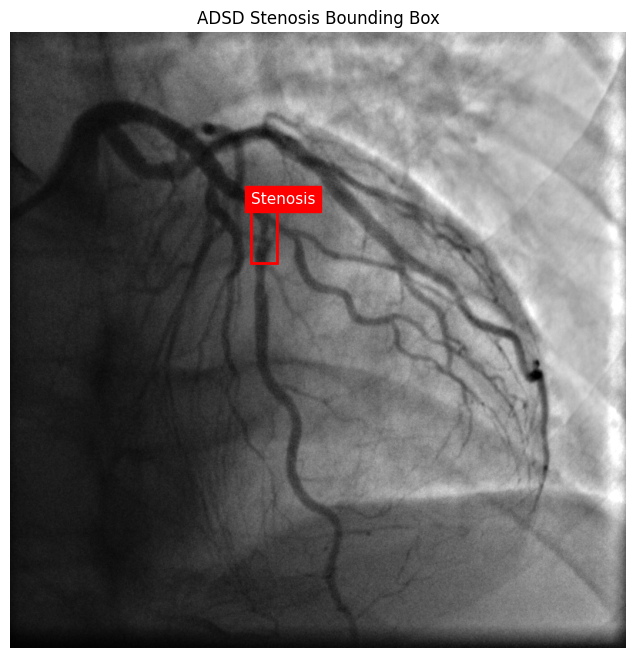

In [ ]:
# @title 바운딩 박스(Bounding Box) 시각화
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET

# 이미지 열기
image = Image.open(sample_image_path).convert("RGB")

# XML 다시 읽기
tree = ET.parse(sample_xml_path)
root = tree.getroot()

# XML 안의 모든 object 확인
objects = root.findall("object")

print("객체 개수:", len(objects))
print("실제 이미지 크기:", image.size)

# 원본 이미지 출력
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image)

for obj in objects:
    class_name = obj.find("name").text

    bbox = obj.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    box_width = xmax - xmin
    box_height = ymax - ymin

    # 빨간색 bounding box
    rectangle = patches.Rectangle(
        (xmin, ymin),
        box_width,
        box_height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)

    # 라벨 표시
    ax.text(
        xmin,
        max(ymin - 8, 0),
        class_name,
        color="white",
        fontsize=11,
        backgroundcolor="red"
    )

    print(
        f"{class_name}: "
        f"({xmin}, {ymin}) ~ "
        f"({xmax}, {ymax})"
    )

ax.set_title("ADSD Stenosis Bounding Box")

ax.axis("off")
plt.show()

- XML 좌표가 실제 협착 부위와 일치하는지 확인
- x축과 y축이 바뀌지 않았는지 확인
- 이미지와 XML 파일이 올바르게 연결됐는지 확인

In [ ]:
# @title 협착 주변 문맥 crop 함수
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def make_context_crop(image, bbox, context_scale=3.0):
    """
    bbox 주변 문맥을 포함한 정사각형 crop 생성

    bbox: (xmin, ymin, xmax, ymax)

    context_scale: bbox 긴 변의 몇 배까지 주변을 포함할지 결정
    """

    xmin, ymin, xmax, ymax = bbox

    bbox_width = xmax - xmin
    bbox_height = ymax - ymin

    # Bounding box 중심
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2

    # 긴 변을 기준으로 정사각형 크기 결정
    crop_size = int(max(bbox_width, bbox_height) * context_scale)

    half_size = (crop_size / 2)

    # 정사각형 crop 좌표
    crop_xmin = int(center_x - half_size)
    crop_ymin = int(center_y - half_size)

    crop_xmax = int(center_x + half_size)
    crop_ymax = int(center_y + half_size)

    image_width, image_height = (image.size)

    # 이미지 경계를 벗어나지 않도록 조정
    crop_xmin = max(crop_xmin, 0)
    crop_ymin = max(crop_ymin, 0)

    crop_xmax = min(crop_xmax, image_width)
    crop_ymax = min(crop_ymax, image_height)

    context_patch = image.crop((crop_xmin, crop_ymin, crop_xmax, crop_ymax))
    crop_bbox = (crop_xmin, crop_ymin, crop_xmax, crop_ymax)

    return context_patch, crop_bbox

In [ ]:
# @title 예시 bbox로 패치 생성
stenosis_bbox = (312, 230, 346, 300)

context_patch, context_bbox = (
    make_context_crop(
        image=image,
        bbox=stenosis_bbox,
        context_scale=3.0
    )
)

print("원본 이미지 크기:", image.size)
print("협착 bbox:", stenosis_bbox)
print("문맥 crop 좌표:", context_bbox)
print("문맥 patch 크기:", context_patch.size)

원본 이미지 크기: (800, 800)
협착 bbox: (312, 230, 346, 300)
문맥 crop 좌표: (224, 160, 434, 370)
문맥 patch 크기: (210, 210)


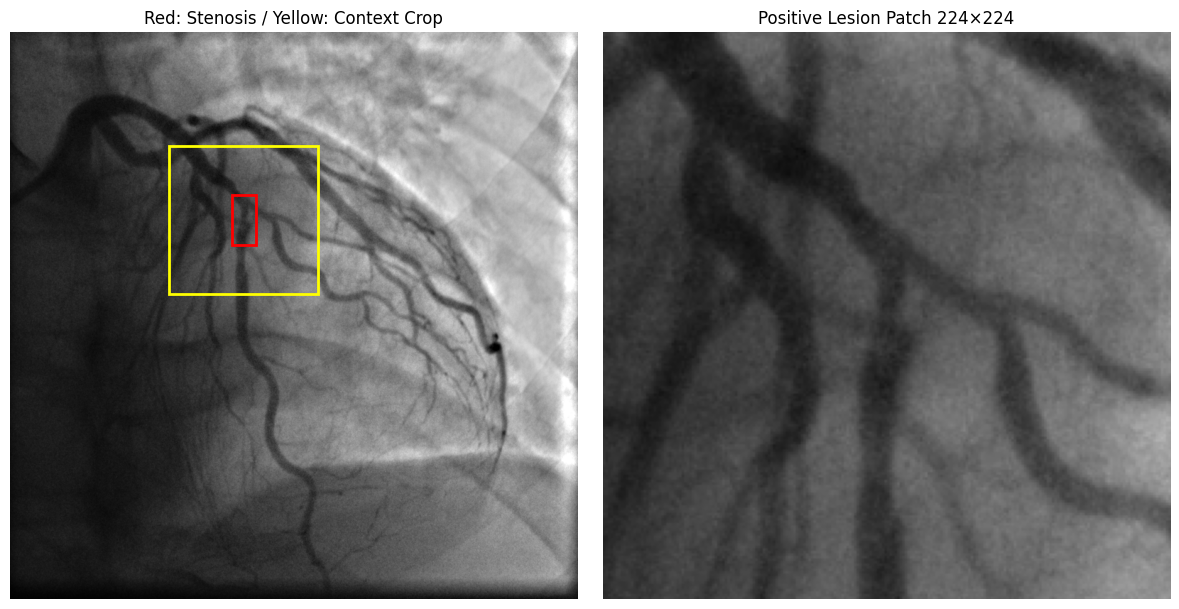

In [ ]:
# @title Positive 패치 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 원본 영상
axes[0].imshow(image)

crop_xmin, crop_ymin, crop_xmax, crop_ymax = (context_bbox)

context_rectangle = patches.Rectangle(
    (crop_xmin, crop_ymin),
    crop_xmax - crop_xmin,
    crop_ymax - crop_ymin,
    linewidth=2,
    edgecolor="yellow",
    facecolor="none")

axes[0].add_patch(context_rectangle)

# 실제 협착 bbox도 표시
xmin, ymin, xmax, ymax = (stenosis_bbox)

stenosis_rectangle = patches.Rectangle(
    (xmin, ymin),
    xmax - xmin,
    ymax - ymin,
    linewidth=2,
    edgecolor="red",
    facecolor="none")

axes[0].add_patch(stenosis_rectangle)
axes[0].set_title("Red: Stenosis / Yellow: Context Crop")
axes[0].axis("off")

# 추출된 병변 patch
axes[1].imshow(context_patch.resize((224, 224)))
axes[1].set_title("Positive Lesion Patch 224×224")
axes[1].axis("off")

plt.tight_layout()
plt.show()

- 빨간색: 실제 협착 bbox
- 노란색: 모델에 넣을 문맥 패치 범위
- 오른쪽: 해당 패치를 224×224로 확대
- => Positive 패치가 실제로 병변과 주변 혈관을 포함하는지 확인

In [ ]:
# @title Negative 후보 영역이 협착 bbox와 겹치는지 검사
def rectangles_overlap(box_a, box_b):
    """
    두 사각형이 서로 겹치는지 확인
    box = (xmin, ymin, xmax, ymax)
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    overlap_width = max(0, min(ax2, bx2) - max(ax1, bx1))
    overlap_height = max(0, min(ay2, by2) - max(ay1, by1))

    return (overlap_width * overlap_height) > 0

In [ ]:
# @title 지정된 중심점에서 같은 크기의 정사각형 패치를 자름
def make_fixed_square_crop(image, center_x, center_y, crop_size):
    """
    지정한 중심에서 동일한 크기의
    정사각형 patch를 생성
    """

    image_width, image_height = image.size

    crop_size = min(
        crop_size,
        image_width,
        image_height
    )

    crop_xmin = int(center_x - crop_size / 2)
    crop_ymin = int(center_y - crop_size / 2)

    # 이미지 경계 안으로 이동
    crop_xmin = max(
        0,
        min(
            crop_xmin,
            image_width - crop_size
        )
    )

    crop_ymin = max(
        0,
        min(
            crop_ymin,
            image_height - crop_size
        )
    )

    crop_xmax = (crop_xmin + crop_size)
    crop_ymax = (crop_ymin + crop_size)

    crop_box = (
        crop_xmin,
        crop_ymin,
        crop_xmax,
        crop_ymax
    )

    patch = image.crop(crop_box)

    return patch, crop_box

In [ ]:
# @title Positive patch의 위·아래·왼쪽·오른쪽에서 negative 후보 제작
# Positive context crop 정보
pos_xmin, pos_ymin, pos_xmax, pos_ymax = (context_bbox)

positive_center_x = (pos_xmin + pos_xmax) / 2
positive_center_y = (pos_ymin + pos_ymax) / 2

positive_crop_size = max(
    pos_xmax - pos_xmin,
    pos_ymax - pos_ymin
)

# Positive patch 기준 4방향 중심점
candidate_centers = {
    "left": (
        positive_center_x - positive_crop_size,
        positive_center_y
    ),

    "right": (
        positive_center_x + positive_crop_size,
        positive_center_y
    ),

    "up": (
        positive_center_x,
        positive_center_y - positive_crop_size
    ),

    "down": (
        positive_center_x,
        positive_center_y + positive_crop_size
    )
}

negative_patches = []

for direction, (center_x, center_y) in candidate_centers.items():

    negative_patch, negative_box = (
        make_fixed_square_crop(
            image=image,
            center_x=center_x,
            center_y=center_y,
            crop_size=positive_crop_size
        )
    )

    # 실제 stenosis bbox와 겹치는 patch는 제외
    if rectangles_overlap(negative_box, stenosis_bbox):
        print(f"{direction}: 병변 bbox와 겹쳐 제외")
        continue

    negative_patches.append({
        "direction": direction,
        "patch": negative_patch,
        "crop_box": negative_box,
        "label": 0
    })

print("생성된 Negative patch 수:", len(negative_patches))

for item in negative_patches:
    print(item["direction"], item["crop_box"])

생성된 Negative patch 수: 4
left (14, 160, 224, 370)
right (434, 160, 644, 370)
up (224, 0, 434, 210)
down (224, 370, 434, 580)


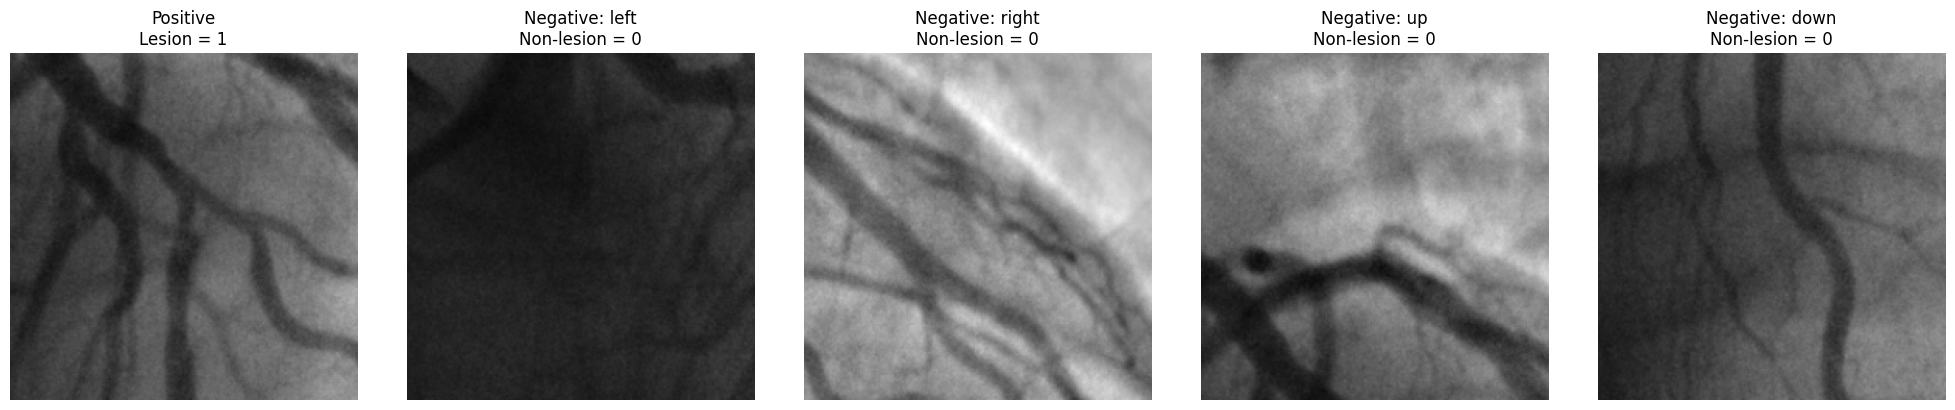

In [ ]:
# @title Positive/Negative 후보 시각화
# Positive 1개와 Negative 후보 최대 4개를 나란히 표시
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Positive patch
axes[0].imshow(context_patch.resize((224, 224)))
axes[0].set_title("Positive\nLesion = 1")
axes[0].axis("off")

# Negative patches
for index, item in enumerate(negative_patches[:4], start=1):
    axes[index].imshow(item["patch"].resize((224, 224)))

    axes[index].set_title(
        f"Negative: {item['direction']}\n"
        f"Non-lesion = 0"
    )

    axes[index].axis("off")

# Negative가 4개보다 적을 경우 빈 칸 처리
for index in range(len(negative_patches) + 1, 5):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# @title Negative 패치 품질 계산
import cv2
import numpy as np
import pandas as pd

def calculate_patch_quality(patch):
    """
    Negative patch 안에 혈관 형태와 경계가
    어느 정도 존재하는지 간단하게 측정
    """

    gray = np.array(
        patch.convert("L"),
        dtype=np.uint8
    )

    # 전체적인 명암 변화
    contrast_score = float(gray.std())

    # Sobel을 이용한 경계 강도
    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_32F,
        1, 0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_32F,
        0, 1,
        ksize=3
    )

    gradient = cv2.magnitude(sobel_x, sobel_y)
    gradient_score = float(gradient.mean())

    # 두 점수를 함께 사용
    quality_score = (contrast_score + gradient_score)

    return {
        "contrast_score": contrast_score,
        "gradient_score": gradient_score,
        "quality_score": quality_score
    }

Negative 후보에 혈관이나 경계가 얼마나 포함됐는지 평가
- contrast_score: 명암 변화의 크기
- gradient_score: Sobel 필터로 계산한 경계 강도
- quality_score = (contrast_score + gradient_score)
- => 단순한 검은 배경보다 혈관 구조가 있는 패치를 선택하기 위한 휴리스틱

In [ ]:
# @title 품질 점수 순위 출력
quality_rows = []

for item in negative_patches:
    scores = calculate_patch_quality(item["patch"])

    quality_rows.append({
        "direction": item["direction"],
        **scores
    })

quality_df = pd.DataFrame(
    quality_rows
).sort_values(
    "quality_score",
    ascending=False
).reset_index(drop=True)

display(quality_df.round(4))

,direction,contrast_score,gradient_score,quality_score
0,up,44.0848,34.7300,78.8148
1,right,35.5294,40.5704,76.0998
2,down,29.9217,26.5868,56.5085
3,left,10.2164,17.3572,27.5736


In [ ]:
# @title 상위 Negative 3개 선택
selected_directions = (
    quality_df
    .head(3)["direction"]
    .tolist()
)

selected_negative_patches = [
    item
    for item in negative_patches
    if item["direction"]
    in selected_directions
]

print("선택된 Negative 방향:", selected_directions)

선택된 Negative 방향: ['up', 'right', 'down']


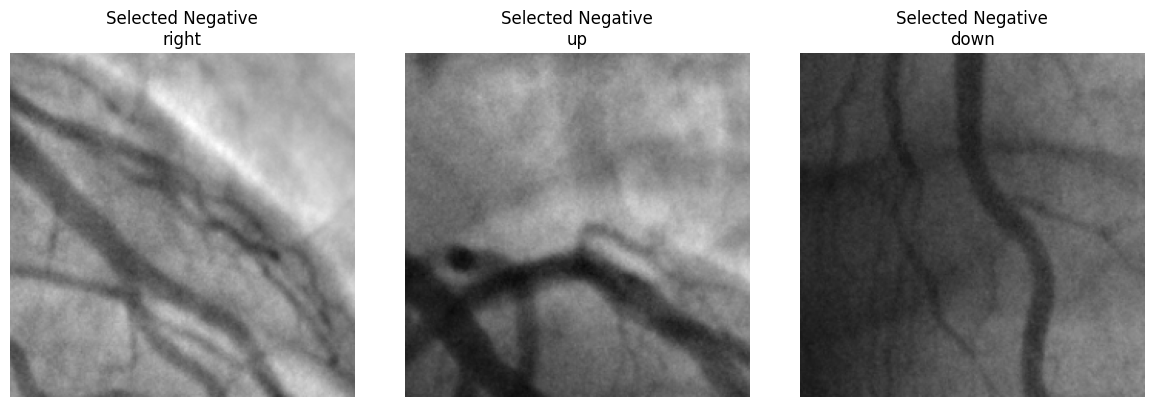

In [ ]:
# @title 선택된 Negative 시각화
fig, axes = plt.subplots(
    1,
    len(selected_negative_patches),
    figsize=(
        4 * len(selected_negative_patches),
        4
    )
)

if len(selected_negative_patches) == 1:
    axes = [axes]

for axis, item in zip(axes, selected_negative_patches):
    axis.imshow(item["patch"].resize((224, 224)))

    axis.set_title(
        f"Selected Negative\n"
        f"{item['direction']}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# @title XML 파싱 함수
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np

def parse_adsd_xml(xml_path):
    """
    Pascal VOC XML에서
    이미지 경로와 모든 stenosis bbox 추출
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text

    image_path = (Path(xml_path).parent / filename)

    bboxes = []

    for obj in root.findall("object"):
        class_name = (
            obj.find("name")
            .text
            .strip()
            .lower()
        )

        if class_name != "stenosis":
            continue

        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))

        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        bboxes.append((xmin, ymin, xmax, ymax))

    return image_path, bboxes

In [ ]:
# @title 이미지 한 장의 전체 패치 기록 생성
def create_adsd_patch_records(xml_path, context_scale=3.0, top_k_negatives=3):
    image_path, lesion_bboxes = (parse_adsd_xml(xml_path))

    if not image_path.exists():
        return []

    if len(lesion_bboxes) == 0:
        return []

    image = Image.open(image_path).convert("RGB")

    filename = image_path.stem

    # 14_081_7_0039 → 14_081
    filename_parts = filename.split("_")

    patient_id = (
        f"{filename_parts[0]}_"
        f"{filename_parts[1]}"
    )

    records = []

    for lesion_index, lesion_bbox in enumerate(lesion_bboxes):
        xmin, ymin, xmax, ymax = (lesion_bbox)

        bbox_width = xmax - xmin
        bbox_height = ymax - ymin

        center_x = (xmin + xmax) / 2
        center_y = (ymin + ymax) / 2

        crop_size = int(
            max(
                bbox_width,
                bbox_height
            )
            * context_scale
        )

        # 너무 작은 patch 방지
        crop_size = max(crop_size, 64)

        # ==================================
        # Positive patch
        # ==================================

        positive_patch, positive_box = (
            make_fixed_square_crop(
                image=image,
                center_x=center_x,
                center_y=center_y,
                crop_size=crop_size
            )
        )

        pxmin, pymin, pxmax, pymax = (positive_box)

        records.append({
            "patient_id": patient_id,
            "image_path": str(image_path),
            "xml_path": str(xml_path),

            "lesion_index": lesion_index,
            "patch_type": "positive",
            "direction": "center",
            "label": 1,

            "crop_xmin": pxmin,
            "crop_ymin": pymin,
            "crop_xmax": pxmax,
            "crop_ymax": pymax,

            "quality_score": np.nan
        })

        # ==================================
        # Negative patch 후보
        # ==================================

        candidate_centers = {
            "left": (
                center_x - crop_size,
                center_y
            ),

            "right": (
                center_x + crop_size,
                center_y
            ),

            "up": (
                center_x,
                center_y - crop_size
            ),

            "down": (
                center_x,
                center_y + crop_size
            )
        }

        negative_candidates = []

        for direction, (
            negative_center_x,
            negative_center_y
        ) in candidate_centers.items():

            negative_patch, negative_box = (
                make_fixed_square_crop(
                    image=image,
                    center_x=negative_center_x,
                    center_y=negative_center_y,
                    crop_size=crop_size
                )
            )

            # 이미지 안의 모든 stenosis bbox와 비교
            overlaps_lesion = any(
                rectangles_overlap(
                    negative_box,
                    existing_bbox
                )
                for existing_bbox
                in lesion_bboxes
            )

            if overlaps_lesion:
                continue

            quality = calculate_patch_quality(negative_patch)

            negative_candidates.append({
                "direction": direction,
                "crop_box": negative_box,
                "quality_score":
                    quality["quality_score"]
            })

        # 품질 점수가 높은 Negative만 선택
        negative_candidates = sorted(
            negative_candidates,
            key=lambda item:
                item["quality_score"],
            reverse=True
        )[:top_k_negatives]

        for candidate in negative_candidates:
            nxmin, nymin, nxmax, nymax = (
                candidate["crop_box"]
            )

            records.append({
                "patient_id": patient_id,
                "image_path": str(image_path),
                "xml_path": str(xml_path),

                "lesion_index": lesion_index,
                "patch_type": "negative",
                "direction":
                    candidate["direction"],
                "label": 0,

                "crop_xmin": nxmin,
                "crop_ymin": nymin,
                "crop_xmax": nxmax,
                "crop_ymax": nymax,

                "quality_score": candidate["quality_score"]
            })

    return records

처리 순서:

- 1. XML에서 모든 협착 bbox 읽기
- 2. bbox 중심 Positive 패치 생성
- 3. 상하좌우 Negative 후보 생성
- 4. 해당 이미지의 모든 협착 bbox와 겹치는 후보 제거
- 5. Negative 품질 점수 계산
- 6. 상위 3개 Negative 선택
- 7. 실제 이미지는 저장하지 않고 crop 좌표만 기록

In [ ]:
# @title XML 20개로 사전 시험
test_xml_paths = sorted(Path("/content/ADSD/dataset").glob("*.xml"))[:20]

test_patch_records = []

for xml_path in test_xml_paths:
    test_patch_records.extend(
        create_adsd_patch_records(
            xml_path=xml_path,
            context_scale=3.0,
            top_k_negatives=3
        )
    )

test_patch_df = pd.DataFrame(test_patch_records)

# 동일한 crop이 중복 생성됐다면 제거
test_patch_df = (
    test_patch_df
    .drop_duplicates(
        subset=[
            "image_path",
            "label",
            "crop_xmin",
            "crop_ymin",
            "crop_xmax",
            "crop_ymax"
        ]
    )
    .reset_index(drop=True)
)

print("시험에 사용한 XML:", len(test_xml_paths))

print("생성된 전체 patch:", len(test_patch_df))

print("\n라벨 분포")
print(
    test_patch_df["label"]
    .value_counts()
    .sort_index()
)

print("\nPatch 종류")
print(
    test_patch_df["patch_type"]
    .value_counts()
)

display(test_patch_df.head(10))

시험에 사용한 XML: 20
생성된 전체 patch: 84

라벨 분포
label
0    63
1    21
Name: count, dtype: int64

Patch 종류
patch_type
negative    63
positive    21
Name: count, dtype: int64


,patient_id,image_path,xml_path,lesion_index,patch_type,direction,label,crop_xmin,crop_ymin,crop_xmax,crop_ymax,quality_score
0,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,positive,center,1,152,117,233,198,NaN
1,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,left,0,71,117,152,198,41.929193
2,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,right,0,233,117,314,198,29.958067
3,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,up,0,152,36,233,117,25.705803
4,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,0,positive,center,1,138,148,202,212,NaN
5,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,0,negative,left,0,74,148,138,212,49.960788
6,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,0,negative,up,0,138,84,202,148,41.576175
7,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,0,negative,down,0,138,212,202,276,12.124883
8,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,1,positive,center,1,199,148,263,212,NaN
9,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,1,negative,up,0,199,84,263,148,24.391272


In [ ]:
# @title 무작위 패치 검증
sample_positive_df = (
    test_patch_df[test_patch_df["label"] == 1
    ].sample(
        n=min(4, (test_patch_df["label"] == 1).sum()),
        random_state=42
    )
)

sample_negative_df = (
    test_patch_df[test_patch_df["label"] == 0
    ].sample(
        n=min(4, (test_patch_df["label"]== 0).sum()),
        random_state=42
    )
)

sample_patch_df = pd.concat(
    [sample_positive_df, sample_negative_df],
    ignore_index=True
)

In [ ]:
def crop_patch_from_row(row):
    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    patch = image.crop(
        (
            int(row["crop_xmin"]),
            int(row["crop_ymin"]),
            int(row["crop_xmax"]),
            int(row["crop_ymax"])
        )
    )

    return patch

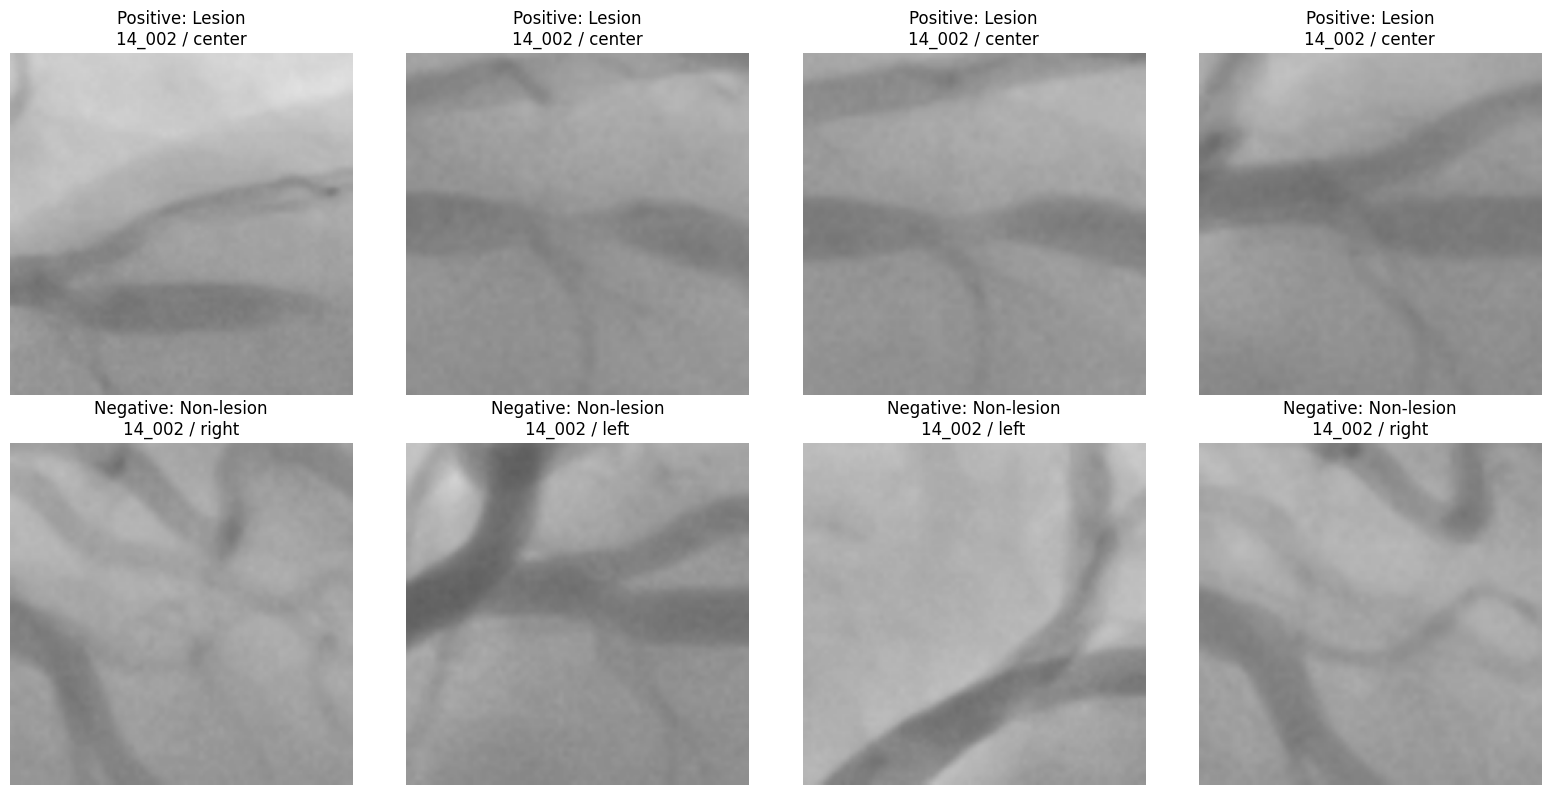

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

for axis, (_, row) in zip(axes, sample_patch_df.iterrows()):
    patch = crop_patch_from_row(row)

    axis.imshow(patch.resize((224, 224)))

    label_name = (
        "Positive: Lesion"
        if row["label"] == 1
        else "Negative: Non-lesion"
    )

    axis.set_title(
        f"{label_name}\n"
        f"{row['patient_id']} / "
        f"{row['direction']}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

Positive와 Negative 각각 4개씩 무작위 선택한 다음 원본 이미지에서 crop해서 시각화
- => 대량 생성 전에 좌표와 라벨이 올바른지 확인하는 품질검사

In [ ]:
# @title 전체 XML 목록 생성
from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd

all_xml_paths = sorted(Path("/content/ADSD/dataset").glob("*.xml"))

print("전체 XML 수:", len(all_xml_paths))

전체 XML 수: 8325


In [ ]:
# @title 전체 패치 생성
all_patch_records = []
failed_xml_paths = []

for xml_path in tqdm(all_xml_paths, desc="ADSD patch 생성"):
    try:
        records = create_adsd_patch_records(
            xml_path=xml_path,
            context_scale=3.0,
            top_k_negatives=3
        )

        all_patch_records.extend(records)

    except Exception as error: # 오류난 XML은 별도 기록
        failed_xml_paths.append({
            "xml_path": str(xml_path),
            "error": str(error)
        })

ADSD patch 생성:   0%|          | 0/8325 [00:00<?, ?it/s]

In [ ]:
# @title DataFrame으로 변환 및 중복 제거
adsd_patch_df = pd.DataFrame(all_patch_records)

print("중복 제거 전 patch 수:", len(adsd_patch_df))

# 같은 이미지에서 동일한 좌표가 여러 번 생성된 경우 제거
adsd_patch_df = (
    adsd_patch_df
    .drop_duplicates(
        subset=[
            "image_path",
            "label",
            "crop_xmin",
            "crop_ymin",
            "crop_xmax",
            "crop_ymax"
        ]
    )
    .reset_index(drop=True)
)

print("중복 제거 후 patch 수:", len(adsd_patch_df))
print("처리 실패 XML 수:", len(failed_xml_paths))

중복 제거 전 patch 수: 32366
중복 제거 후 patch 수: 32366
처리 실패 XML 수: 0


In [ ]:
# @title 환자 split 연결 및 누수 확인
adsd_split_path = ("/content/drive/MyDrive/dataset_medical/adsd_patient_split.csv")

adsd_split_info = pd.read_csv(
    adsd_split_path,
    dtype={"patient_id": str}
)

adsd_split_info["patient_id"] = (
    adsd_split_info["patient_id"]
    .astype(str)
    .str.strip()
)

adsd_split_info["split"] = (
    adsd_split_info["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
# 환자 한 명이 여러 split에 들어 있지 않은지 확인
patient_split_count = (
    adsd_split_info
    .groupby("patient_id")["split"]
    .nunique()
)

leaked_patients = (patient_split_count[patient_split_count > 1])

print("여러 split에 포함된 ADSD 환자 수:", len(leaked_patients))

if len(leaked_patients) > 0:
    raise ValueError("ADSD patient split에 데이터 누수가 있습니다.")

여러 split에 포함된 ADSD 환자 수: 0


In [ ]:
# split 정보를 patch DataFrame에 붙이기
split_mapping_df = (adsd_split_info[["patient_id", "split"]].drop_duplicates(subset=["patient_id"]))

adsd_patch_df = adsd_patch_df.merge(
    split_mapping_df,
    on="patient_id",
    how="left"
)

missing_split_count = (
    adsd_patch_df["split"]
    .isna()
    .sum()
)

print("split을 찾지 못한 patch 수:", missing_split_count)

if missing_split_count > 0:
    missing_patients = (
        adsd_patch_df.loc[
            adsd_patch_df["split"].isna(),
            "patient_id"
        ]
        .unique()
    )

    print("split 누락 환자:", missing_patients)

    raise ValueError("일부 환자의 split을 찾지 못했습니다.")

split을 찾지 못한 patch 수: 0


In [ ]:
# @title 최종 패치 분포 확인
print("\nADSD 전체 patch 라벨 분포")

print(
    adsd_patch_df["label"]
    .value_counts()
    .sort_index()
)

print("\nSplit × Label 분포")

print(
    pd.crosstab(
        adsd_patch_df["split"],
        adsd_patch_df["label"],
        margins=True
    )
)

print("\nSplit별 환자 수")

print(
    adsd_patch_df
    .groupby("split")["patient_id"]
    .nunique()
)

display(adsd_patch_df.head())


ADSD 전체 patch 라벨 분포
label
0    24040
1     8326
Name: count, dtype: int64

Split × Label 분포
label      0     1    All
split                    
test    3618  1235   4853
train  16784  5830  22614
val     3638  1261   4899
All    24040  8326  32366

Split별 환자 수
split
test      9
train    45
val      10
Name: patient_id, dtype: int64


,patient_id,image_path,xml_path,lesion_index,patch_type,direction,label,crop_xmin,crop_ymin,crop_xmax,crop_ymax,quality_score,split
0,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,positive,center,1,152,117,233,198,NaN,train
1,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,left,0,71,117,152,198,41.929193,train
2,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,right,0,233,117,314,198,29.958067,train
3,14_002,/content/ADSD/dataset/14_002_5_0016.bmp,/content/ADSD/dataset/14_002_5_0016.xml,0,negative,up,0,152,36,233,117,25.705803,train
4,14_002,/content/ADSD/dataset/14_002_5_0017.bmp,/content/ADSD/dataset/14_002_5_0017.xml,0,positive,center,1,138,148,202,212,NaN,train


In [ ]:
# @title 패치 metadata 저장
patch_csv_path = (
    "/content/drive/MyDrive/"
    "dataset_medical/"
    "adsd_patch_metadata.csv"
)

adsd_patch_df.to_csv(
    patch_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("ADSD patch metadata 저장 완료:")
print(patch_csv_path)

ADSD patch metadata 저장 완료:
/content/drive/MyDrive/dataset_medical/adsd_patch_metadata.csv


In [ ]:
# @title ADSD Dataset/DataLoader
from PIL import Image
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# =========================================================
# 1. ADSD patch metadata 불러오기
# =========================================================

metadata_path = (
    "/content/drive/MyDrive/dataset_medical/"
    "adsd_patch_metadata.csv"
)

patch_df = pd.read_csv(metadata_path)

print("전체 patch 수:", len(patch_df))

display(
    pd.crosstab(
        patch_df["split"],
        patch_df["label"],
        margins=True
    )
)

# =========================================================
# 2. 환자 단위 데이터 누수 확인
# =========================================================

train_patients = set(
    patch_df.loc[
        patch_df["split"] == "train",
        "patient_id"
    ].astype(str)
)

val_patients = set(
    patch_df.loc[
        patch_df["split"] == "val",
        "patient_id"
    ].astype(str)
)

test_patients = set(
    patch_df.loc[
        patch_df["split"] == "test",
        "patient_id"
    ].astype(str)
)

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("환자 단위 데이터 누수 없음")

# =========================================================
# 3. 이미지 전처리
# =========================================================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# 학습 데이터에만 augmentation 적용
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        fill=0
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Validation/Test에는 augmentation 적용하지 않음
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# =========================================================
# 4. ADSD Patch Dataset
# =========================================================

class ADSDPatchDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # 원본 ADSD 이미지 읽기
        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

            # metadata에 저장된 좌표로 patch 추출
            crop_box = (
                int(row["crop_xmin"]),
                int(row["crop_ymin"]),
                int(row["crop_xmax"]),
                int(row["crop_ymax"])
            )

            patch = image.crop(crop_box)

        if self.transform is not None:
            patch = self.transform(patch)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return patch, label

# =========================================================
# 5. Split별 Dataset 생성
# =========================================================

train_df = patch_df[patch_df["split"] == "train"].copy()
val_df = patch_df[patch_df["split"] == "val"].copy()
test_df = patch_df[patch_df["split"] == "test"].copy()


train_dataset = ADSDPatchDataset(
    train_df,
    transform=train_transform)

val_dataset = ADSDPatchDataset(
    val_df,
    transform=eval_transform)

test_dataset = ADSDPatchDataset(
    test_df,
    transform=eval_transform)

print("Train patch:", len(train_dataset))
print("Validation patch:", len(val_dataset))
print("Test patch:", len(test_dataset))

# =========================================================
# 6. DataLoader 생성
# =========================================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# 7. 한 배치가 정상적으로 나오는지 확인
# =========================================================

images, labels = next(iter(train_loader))

print("이미지 배치 크기:", images.shape)
print("라벨 배치 크기:", labels.shape)
print("배치 라벨 분포:", torch.bincount(labels))

전체 patch 수: 32366


label,0,1,All
split,,,
test,3618,1235,4853
train,16784,5830,22614
val,3638,1261,4899
All,24040,8326,32366


환자 단위 데이터 누수 없음
Train patch: 22614
Validation patch: 4899
Test patch: 4853
이미지 배치 크기: torch.Size([32, 3, 224, 224])
라벨 배치 크기: torch.Size([32])
배치 라벨 분포: tensor([19, 13])


전처리:

- Train: Resize, RandomAffine, 밝기/대비 변화, Normalize
- Val/Test: Resize, Normalize만 적용

In [ ]:
# @title ADSD class weight
import torch

# Train 데이터의 클래스별 개수
train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

negative_count = train_class_counts[0]
positive_count = train_class_counts[1]
total_count = negative_count + positive_count

# 전체 개수 / (클래스 수 × 해당 클래스 개수)
negative_weight = (total_count / (2 * negative_count))
positive_weight = (total_count / (2 * positive_count))

class_weights = torch.tensor(
    [negative_weight, positive_weight],
    dtype=torch.float32)

print("Train 클래스 개수", train_class_counts)

print("\nNegative 가중치:", round(negative_weight, 4))
print("Positive 가중치:", round(positive_weight, 4))

print("\n최종 class weights:", class_weights)

Train 클래스 개수 label
0    16784
1     5830
Name: count, dtype: int64

Negative 가중치: 0.6737
Positive 가중치: 1.9395

최종 class weights: tensor([0.6737, 1.9395])


ADSD Train은 Negative가 약 3배 많으므로 Positive 오류에 더 큰 가중치를 줌

- Negative weight: 0.6737
- Positive weight: 1.9395

In [ ]:
# @title EfficientNet-B0 생성
import torch
import torch.nn as nn

from torchvision.models import (efficientnet_b0, EfficientNet_B0_Weights)

# =========================================================
# 1. GPU 설정
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

# =========================================================
# 2. ImageNet 사전학습 EfficientNet-B0 불러오기
# =========================================================

weights = EfficientNet_B0_Weights.DEFAULT
adsd_model = efficientnet_b0(weights=weights)

# =========================================================
# 3. 마지막 분류층을 ADSD 이진 분류용으로 변경
# =========================================================

in_features = adsd_model.classifier[1].in_features

adsd_model.classifier[1] = nn.Linear(
    in_features=in_features,
    out_features=2)

adsd_model = adsd_model.to(device)

# =========================================================
# 4. 파라미터 수 확인
# =========================================================

total_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)

# =========================================================
# 5. 실제 이미지 한 배치로 출력 형태 확인
# =========================================================

sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images[:2].to(device)

adsd_model.eval()

with torch.no_grad():
    sample_outputs = adsd_model(sample_images)

print("\n입력 크기:", sample_images.shape)
print("모델 출력 크기:", sample_outputs.shape)
print("모델 출력 예시:")
print(sample_outputs)

사용 장치: cuda
전체 파라미터: 4,010,110
학습 가능 파라미터: 4,010,110
학습 가능 비율: 100.00%

입력 크기: torch.Size([2, 3, 224, 224])
모델 출력 크기: torch.Size([2, 2])
모델 출력 예시:
tensor([[ 0.3274, -0.3077],
        [-0.0892, -0.2305]], device='cuda:0')


In [ ]:
# @title ADSD 분류층 워밍업
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (f1_score, balanced_accuracy_score)

# =========================================================
# 1. Backbone 고정, 분류층만 학습 가능하게 설정
# =========================================================

for parameter in adsd_model.features.parameters():
    parameter.requires_grad = False

for parameter in adsd_model.classifier.parameters():
    parameter.requires_grad = True


total_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)


# =========================================================
# 2. Loss와 Optimizer
# =========================================================

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = torch.optim.AdamW(
    adsd_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# =========================================================
# 3. 한 epoch 실행 함수
# =========================================================

def run_adsd_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()

        # 고정된 backbone의 BatchNorm 통계도 변경하지 않음
        model.features.eval()

        # 마지막 classifier만 학습 모드
        model.classifier.train()

    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:

        images = images.to(device, non_blocking=True)

        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(images)

            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += (loss.item() * images.size(0))

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    epoch_loss = (running_loss / len(data_loader.dataset))

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    epoch_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    return {
        "loss": epoch_loss,
        "f1": epoch_f1,
        "balanced_accuracy": (
            epoch_balanced_accuracy
        )
    }


# =========================================================
# 4. 분류층 워밍업 학습
# =========================================================

checkpoint_dir = Path(
    "/content/drive/MyDrive/"
    "dataset_medical/cadica_models"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

warmup_checkpoint_path = (checkpoint_dir / "ADSD_efficientnet_b0_warmup_best.pt")

warmup_epochs = 3
best_val_balanced_accuracy = -1.0

warmup_history = []

for epoch in range(warmup_epochs):

    train_result = run_adsd_epoch(
        model=adsd_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer
    )

    val_result = run_adsd_epoch(
        model=adsd_model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None
    )

    warmup_history.append({
        "epoch": epoch + 1,

        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),

        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/{warmup_epochs} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Train F1 {train_result['f1']:.4f} | "
        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Val F1 {val_result['f1']:.4f} | "
        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f}"
    )

    if (val_result["balanced_accuracy"] > best_val_balanced_accuracy):
        best_val_balanced_accuracy = (val_result["balanced_accuracy"])

        torch.save(
            adsd_model.state_dict(),
            warmup_checkpoint_path
        )

        print("→ 최고 워밍업 모델 저장:", warmup_checkpoint_path)

# =========================================================
# 5. 최고 워밍업 모델 다시 불러오기
# =========================================================

adsd_model.load_state_dict(
    torch.load(
        warmup_checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\n최고 Validation Balanced Accuracy:",
    round(best_val_balanced_accuracy, 4)
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 2,562
학습 가능 비율: 0.06%
Epoch 01/3 | Train Loss 0.5483 | Train F1 0.5678 | Train Bal Acc 0.7180 | Val Loss 0.5069 | Val F1 0.5982 | Val Bal Acc 0.7563
  → 최고 워밍업 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/ADSD_efficientnet_b0_warmup_best.pt
Epoch 02/3 | Train Loss 0.4960 | Train F1 0.6233 | Train Bal Acc 0.7634 | Val Loss 0.4818 | Val F1 0.6192 | Val Bal Acc 0.7622
  → 최고 워밍업 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/ADSD_efficientnet_b0_warmup_best.pt
Epoch 03/3 | Train Loss 0.4817 | Train F1 0.6317 | Train Bal Acc 0.7702 | Val Loss 0.4857 | Val F1 0.6171 | Val Bal Acc 0.7562

최고 Validation Balanced Accuracy: 0.7622


Backbone은 고정하고 마지막 classifier만 3 epoch 학습

- 학습 가능 파라미터: 2,562
- 학습 가능 비율: 0.06%

=> 새 분류층이 무작위 초기화됐기 때문에 먼저 분류층만 안정시키는 과정

- 최고 Validation Balanced Accuracy: 0.7622

In [ ]:
# @title ADSD 부분 미세조정
import torch
import torch.nn as nn

# =========================================================
# 1. 최고 워밍업 모델 확인 및 불러오기
# =========================================================

adsd_model.load_state_dict(
    torch.load(
        warmup_checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

# =========================================================
# 2. 전체 backbone을 먼저 고정
# =========================================================

for parameter in adsd_model.features.parameters():
    parameter.requires_grad = False


# EfficientNet 뒤쪽 특징 추출층만 해제
for parameter in adsd_model.features[6:].parameters():
    parameter.requires_grad = True


# 분류층은 계속 학습
for parameter in adsd_model.classifier.parameters():
    parameter.requires_grad = True

# =========================================================
# 3. 학습 가능 파라미터 확인
# =========================================================

total_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in adsd_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)

# =========================================================
# 4. 미세조정용 epoch 함수
# =========================================================

def set_batchnorm_eval(module):
    """작은 batch에서 BatchNorm 통계가 흔들리지 않도록 고정"""
    if isinstance(module, nn.BatchNorm2d):
        module.eval()

def run_adsd_finetune_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()

        # BatchNorm의 running mean/variance는 고정
        model.apply(set_batchnorm_eval)

    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for images, labels in data_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()

                # 지나치게 큰 gradient 방지
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        running_loss += (loss.item() * images.size(0))

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    epoch_loss = (running_loss / len(data_loader.dataset))

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    epoch_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    return {
        "loss": epoch_loss,
        "f1": epoch_f1,
        "balanced_accuracy": (
            epoch_balanced_accuracy
        )
    }

# =========================================================
# 5. 서로 다른 learning rate 설정
# =========================================================

backbone_parameters = [
    parameter
    for parameter
    in adsd_model.features[6:].parameters()
    if parameter.requires_grad
]

classifier_parameters = [
    parameter
    for parameter
    in adsd_model.classifier.parameters()
    if parameter.requires_grad
]


finetune_optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_parameters,
            "lr": 1e-5
        },
        {
            "params": classifier_parameters,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)


finetune_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        finetune_optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )
)

# =========================================================
# 6. 부분 미세조정
# =========================================================

finetune_checkpoint_path = (checkpoint_dir / "ADSD_efficientnet_b0_finetuned_best.pt")

finetune_epochs = 8
early_stopping_patience = 3

best_val_balanced_accuracy = -1.0
epochs_without_improvement = 0
finetune_history = []


for epoch in range(finetune_epochs):

    train_result = run_adsd_finetune_epoch(
        model=adsd_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=finetune_optimizer
    )

    val_result = run_adsd_finetune_epoch(
        model=adsd_model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None
    )

    finetune_scheduler.step(val_result["balanced_accuracy"])

    backbone_lr = (
        finetune_optimizer
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        finetune_optimizer
        .param_groups[1]["lr"]
    )

    finetune_history.append({
        "epoch": epoch + 1,
        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),
        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/{finetune_epochs} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Train F1 {train_result['f1']:.4f} | "
        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Val F1 {val_result['f1']:.4f} | "
        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f} | "
        f"LR {backbone_lr:.1e}/{classifier_lr:.1e}"
    )

    if (val_result["balanced_accuracy"] > best_val_balanced_accuracy):
        best_val_balanced_accuracy = (val_result["balanced_accuracy"])

        epochs_without_improvement = 0

        torch.save(
            adsd_model.state_dict(),
            finetune_checkpoint_path
        )

        print(
            "  → 최고 미세조정 모델 저장:",
            finetune_checkpoint_path
        )

    else:
        epochs_without_improvement += 1

        if (epochs_without_improvement >= early_stopping_patience):
            print("  → Early stopping")
            break

# 최고 미세조정 모델 불러오기
adsd_model.load_state_dict(
    torch.load(
        finetune_checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\n최고 Validation Balanced Accuracy:",
    round(best_val_balanced_accuracy, 4)
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 3,158,302
학습 가능 비율: 78.76%
Epoch 01/8 | Train Loss 0.4256 | Train F1 0.6755 | Train Bal Acc 0.8021 | Val Loss 0.4488 | Val F1 0.6796 | Val Bal Acc 0.7954 | LR 1.0e-05/1.0e-04
  → 최고 미세조정 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/ADSD_efficientnet_b0_finetuned_best.pt
Epoch 02/8 | Train Loss 0.3090 | Train F1 0.7712 | Train Bal Acc 0.8699 | Val Loss 0.4615 | Val F1 0.6891 | Val Bal Acc 0.7896 | LR 1.0e-05/1.0e-04
Epoch 03/8 | Train Loss 0.2476 | Train F1 0.8187 | Train Bal Acc 0.8993 | Val Loss 0.4201 | Val F1 0.7184 | Val Bal Acc 0.8175 | LR 1.0e-05/1.0e-04
  → 최고 미세조정 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/ADSD_efficientnet_b0_finetuned_best.pt
Epoch 04/8 | Train Loss 0.2080 | Train F1 0.8456 | Train Bal Acc 0.9147 | Val Loss 0.4195 | Val F1 0.7159 | Val Bal Acc 0.8129 | LR 1.0e-05/1.0e-04
Epoch 05/8 | Train Loss 0.1777 | Train F1 0.8724 | Train Bal Acc 0.9304 | Val Loss 0.4367 | Val F1 0.7296 | Val Bal Acc 0.8240 |

EfficientNet의 뒤쪽 features[6:]를 해제

- 학습 가능 비율: 78.76%

학습률을 다르게 적용

- Backbone: 1e-5
- Classifier: 1e-4

추가 기능:

- BatchNorm 통계 고정
- Gradient clipping
- Validation 성능 정체 시 학습률 감소
- Early stopping
- 최고 Validation 모델 저장

=> 최고 Validation Balanced Accuracy: 0.8362

In [ ]:
# @title ADSD Test 평가
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# 1. 최고 ADSD 미세조정 모델 불러오기
# =========================================================

adsd_model.load_state_dict(
    torch.load(
        finetune_checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

adsd_model.eval()

# =========================================================
# 2. ADSD Test 평가
# =========================================================

test_running_loss = 0.0

test_labels = []
test_predictions = []
test_probabilities = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device,non_blocking=True)
        labels = labels.to(device,non_blocking=True)

        outputs = adsd_model(images)
        loss = criterion(outputs,labels)

        probabilities = torch.softmax(outputs,dim=1)[:, 1]
        predictions = outputs.argmax(dim=1)

        test_running_loss += (loss.item()* images.size(0))
        test_labels.extend(labels.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_labels = np.asarray(test_labels)
test_predictions = np.asarray(test_predictions)
test_probabilities = np.asarray(test_probabilities)

# =========================================================
# 3. 평가 지표 계산
# =========================================================

test_loss = (test_running_loss / len(test_loader.dataset))

test_accuracy = accuracy_score(test_labels,test_predictions)

test_balanced_accuracy = (
    balanced_accuracy_score(
        test_labels,
        test_predictions
    )
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

test_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1]
).ravel()

test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

# =========================================================
# 4. 결과 출력
# =========================================================

print("ADSD EfficientNet-B0 Test 결과")
print(f"loss: {test_loss:.4f}")
print(f"accuracy: {test_accuracy:.4f}")
print(
    "balanced_accuracy:",
    f"{test_balanced_accuracy:.4f}"
)
print(f"precision: {test_precision:.4f}")
print(f"recall: {test_recall:.4f}")
print(f"specificity: {test_specificity:.4f}")
print(f"f1: {test_f1:.4f}")
print(f"auc: {test_auc:.4f}")


print("\nConfusion Matrix")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\n분류 리포트")
print(
    classification_report(
        test_labels,
        test_predictions,
        labels=[0, 1],
        target_names=[
            "non-annotated patch",
            "stenosis patch"
        ],
        digits=4,
        zero_division=0
    )
)

ADSD EfficientNet-B0 Test 결과
loss: 0.4479
accuracy: 0.8617
balanced_accuracy: 0.8601
precision: 0.6817
recall: 0.8567
specificity: 0.8635
f1: 0.7592
auc: 0.9256

Confusion Matrix
[[3124  494]
 [ 177 1058]]

분류 리포트
                     precision    recall  f1-score   support

non-annotated patch     0.9464    0.8635    0.9030      3618
     stenosis patch     0.6817    0.8567    0.7592      1235

           accuracy                         0.8617      4853
          macro avg     0.8140    0.8601    0.8311      4853
       weighted avg     0.8790    0.8617    0.8664      4853



최고 ADSD 모델을 Test에 한 번 적용한 주요 결과:

- Accuracy: 0.8617
- Balanced Accuracy: 0.8601
- F1: 0.7592
- AUC: 0.9256

=> CADICA 전체 프레임 결과가 아니라 ADSD ROI 패치 분류 성능

In [ ]:
# @title ADSD backbone만 저장
from torchvision.models import efficientnet_b0
import torch

# =========================================================
# 1. 최고 ADSD 모델 불러오기
# =========================================================

adsd_model.load_state_dict(
    torch.load(
        finetune_checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

# =========================================================
# 2. EfficientNet features만 CPU 상태로 저장
# =========================================================

adsd_backbone_path = (checkpoint_dir / "ADSD_efficientnet_b0_backbone_only.pt")

backbone_state_dict = {
    key: value.detach().cpu()
    for key, value
    in adsd_model.features.state_dict().items()
}

torch.save(backbone_state_dict, adsd_backbone_path)

print("ADSD backbone 저장 완료:", adsd_backbone_path)

# =========================================================
# 3. 새 EfficientNet에 정상적으로 로드되는지 검증
# =========================================================

verification_model = efficientnet_b0(weights=None)

load_result = (
    verification_model
    .features
    .load_state_dict(
        torch.load(
            adsd_backbone_path,
            map_location="cpu",
            weights_only=True
        )
    )
)

print("Backbone 로드 검증:", load_result)

del verification_model

ADSD backbone 저장 완료: /content/drive/MyDrive/dataset_medical/cadica_models/ADSD_efficientnet_b0_backbone_only.pt
Backbone 로드 검증: <All keys matched successfully>


In [ ]:
# @title CADICA용 EfficientNet-B0 생성
import torch
import torch.nn as nn

from torchvision.models import efficientnet_b0

# =========================================================
# 1. CADICA용 EfficientNet-B0 생성 함수
# =========================================================

def build_adsd_pretrained_cadica_model(backbone_path, num_classes=2, random_seed=42):
    # CADICA 분류층 초기화를 재현 가능하게 설정
    torch.manual_seed(random_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)

    # ImageNet weight를 다시 불러오지 않음
    # ADSD backbone 안에 ImageNet + ADSD 학습 결과가 들어 있음
    model = efficientnet_b0(weights=None)

    # ADSD로 학습한 특징 추출기만 로드
    adsd_backbone_weights = torch.load(
        backbone_path,
        map_location="cpu",
        weights_only=True
    )

    load_result = (model.features.load_state_dict(adsd_backbone_weights))

    print("ADSD backbone 로드:", load_result)

    # ADSD 분류층은 사용하지 않고 CADICA용 분류층을 새로 생성
    in_features = (model.classifier[1].in_features)
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

# =========================================================
# 2. CADICA용 모델 생성
# =========================================================

cadica_adsd_model = (
    build_adsd_pretrained_cadica_model(
        backbone_path=adsd_backbone_path,
        num_classes=2,
        random_seed=42
    )
)

cadica_adsd_model = (cadica_adsd_model.to(device))

# =========================================================
# 3. 모델 구조 및 파라미터 확인
# =========================================================

total_parameters = sum(
    parameter.numel()
    for parameter
    in cadica_adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in cadica_adsd_model.parameters()
    if parameter.requires_grad
)

print("\n전체 파라미터:", f"{total_parameters:,}")
print(
    "현재 학습 가능 파라미터:",
    f"{trainable_parameters:,}"
)
print("출력 클래스 수:", cadica_adsd_model.classifier[1].out_features)

ADSD backbone 로드: <All keys matched successfully>

전체 파라미터: 4,010,110
현재 학습 가능 파라미터: 4,010,110
출력 클래스 수: 2


새 EfficientNet-B0 구조를 만들고 ADSD backbone을 불러옴

CADICA용 새 분류층 구조: ADSD로 학습된 features + 새 CADICA classifier

In [ ]:
# @title CADICA 통합 데이터 구성
from pathlib import Path
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# =========================================================
# 1. CADICA 경로 설정
# =========================================================

csv_path = (
    "/content/drive/MyDrive/"
    "dataset_medical/common_split.csv"
)

cadica_base = Path(
    "/content/CADICA/CADICA/selectedVideos"
)

if not cadica_base.exists():
    raise FileNotFoundError(
        f"CADICA 폴더가 없습니다: {cadica_base}")

# ID가 숫자로 바뀌지 않도록 문자열로 읽기
video_df = pd.read_csv(
    csv_path,
    dtype={"patient_id": str, "video_id": str})

# 문자열 형식 통일
video_df["label"] = (
    video_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

video_df["view"] = (
    video_df["view"]
    .astype(str)
    .str.strip()
    .str.upper()
)

video_df["split"] = (
    video_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Video 단위 CSV 행 수:", len(video_df))
print("Split 종류:", video_df["split"].unique())
print("View 종류:", video_df["view"].unique())
print("Label 종류:", video_df["label"].unique())

# =========================================================
# 2. selectedFrames.txt를 이용한 Keyframe 확장
# =========================================================

missing_selected_files = []
missing_input_folders = []

def expand_to_keyframes(row):

    patient_id = str(row["patient_id"])
    video_id = str(row["video_id"])

    video_dir = (cadica_base / patient_id / video_id)
    input_dir = (video_dir / "input")

    selected_file = (video_dir / f"{patient_id}_{video_id}_selectedFrames.txt")

    if not input_dir.exists():
        missing_input_folders.append(str(input_dir))
        return []

    if not selected_file.exists():
        missing_selected_files.append(str(selected_file))
        return []

    # selectedFrames.txt에 적힌 프레임 번호 읽기
    with open(selected_file, "r", encoding="utf-8") as file:

        selected_frame_numbers = {
            line.strip()
            .replace(".png", "")
            .split("_")[-1]

            for line in file
            if line.strip()
        }

    frame_rows = []

    for png_path in sorted(input_dir.glob("*.png")):

        frame_number = (
            png_path.stem
            .split("_")[-1])

        if (frame_number not in selected_frame_numbers):
            continue

        frame_rows.append({
            "patient_id": patient_id,
            "video_id": video_id,

            "group_id": (f"{patient_id}_{video_id}"),

            "frame_path": str(png_path),
            "frame_id": png_path.stem,
            "frame_number": frame_number,

            "label": row["label"],
            "view": row["view"],
            "split": row["split"]
        })

    return frame_rows


all_frames = []

for _, row in video_df.iterrows():
    all_frames.extend(
        expand_to_keyframes(row))

frame_df = pd.DataFrame(all_frames)

# LCA와 RCA를 모두 포함하되 별도로 나누지 않음
frame_df = (frame_df[frame_df["view"].isin(["LCA", "RCA"])].reset_index(drop=True))

print("\n중복 제거 전 Keyframe 수:", len(frame_df))
print("없는 input 폴더 수:", len(missing_input_folders))
print("없는 selectedFrames 파일 수:", len(missing_selected_files))

# =========================================================
# 3. 동일한 이미지 경로 중복 확인 및 제거
# =========================================================

duplicate_count = (
    frame_df
    .duplicated(
        subset=["frame_path"]
    ).sum()
)

print("중복 frame_path 수:", duplicate_count)

# 같은 이미지 경로가 여러 번 들어갔다면 1개만 유지
frame_df = (frame_df.drop_duplicates(subset=["frame_path"],keep="first").reset_index(drop=True))

print("중복 제거 후 최종 Keyframe 수:", len(frame_df))

# =========================================================
# 4. 데이터 분포와 누수 확인
# =========================================================

print("\nSplit × Label 분포")

display(
    pd.crosstab(
        frame_df["split"],
        frame_df["label"],
        margins=True
    )
)

print("\nSplit × View 분포")

display(
    pd.crosstab(
        frame_df["split"],
        frame_df["view"],
        margins=True
    )
)

# 동일 영상이 여러 split에 들어갔는지 확인
video_split_count = (
    frame_df
    .groupby(
        ["patient_id", "video_id"]
    )["split"]
    .nunique()
)

leaked_video_count = (
    video_split_count > 1
).sum()

# 동일 환자가 여러 split에 들어갔는지 확인
patient_split_count = (
    frame_df
    .groupby("patient_id")["split"]
    .nunique()
)

leaked_patient_count = (patient_split_count > 1).sum()

print("여러 split에 포함된 영상 수:", leaked_video_count)
print("여러 split에 포함된 환자 수:", leaked_patient_count)

assert leaked_video_count == 0, ("영상 단위 데이터 누수가 있습니다.")
assert leaked_patient_count == 0, ("환자 단위 데이터 누수가 있습니다.")

# =========================================================
# 5. CADICA 전처리
# =========================================================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Train에만 논문 기반 augmentation 적용
cadica_train_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.RandomAffine(
        degrees=25,
        translate=(25 / 224, 25 / 224),
        scale=(0.8, 1.7),
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


# Validation/Test에는 무작위 증강 미적용
cadica_eval_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# =========================================================
# 6. 통합 CADICA Dataset
# =========================================================

class CADICACombinedDataset(Dataset):

    def __init__(self, dataframe, split, transform=None):
        self.data = (
            dataframe[
                dataframe["split"] == split
            ]
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

        self.label_map = {
            "non-lesion": 0,
            "lesion": 1
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]

        with Image.open(row["frame_path"]) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.label_map[row["label"]]

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

# =========================================================
# 7. 통합 Dataset 생성
# =========================================================

cadica_train_dataset = (
    CADICACombinedDataset(
        dataframe=frame_df,
        split="train",
        transform=cadica_train_transform
    )
)

cadica_val_dataset = (
    CADICACombinedDataset(
        dataframe=frame_df,
        split="val",
        transform=cadica_eval_transform
    )
)

cadica_test_dataset = (
    CADICACombinedDataset(
        dataframe=frame_df,
        split="test",
        transform=cadica_eval_transform
    )
)

print("\n통합 Train 이미지:", len(cadica_train_dataset))
print("통합 Validation 이미지:", len(cadica_val_dataset))
print("통합 Test 이미지:", len(cadica_test_dataset))

print(
    "통합 전체 이미지:",
    len(cadica_train_dataset)
    + len(cadica_val_dataset)
    + len(cadica_test_dataset)
)

# =========================================================
# 8. 통합 DataLoader 생성
# =========================================================

cadica_batch_size = 32

cadica_train_loader = DataLoader(
    cadica_train_dataset,
    batch_size=cadica_batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cadica_val_loader = DataLoader(
    cadica_val_dataset,
    batch_size=cadica_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

cadica_test_loader = DataLoader(
    cadica_test_dataset,
    batch_size=cadica_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

cadica_data = {
    "train_loader": cadica_train_loader,
    "val_loader": cadica_val_loader,
    "test_loader": cadica_test_loader
}

# =========================================================
# 9. 한 배치 확인
# =========================================================

cadica_images, cadica_labels = next(iter(cadica_train_loader))

print("\n이미지 배치 크기:", cadica_images.shape)

print("라벨 배치 크기:", cadica_labels.shape)

print(
    "배치 라벨 분포:",
    torch.bincount(
        cadica_labels,
        minlength=2
    )
)

print(
    "이미지 값 범위:",
    round(cadica_images.min().item(), 4),
    "~",
    round(cadica_images.max().item(), 4)
)

Video 단위 CSV 행 수: 334
Split 종류: ['train' 'val' 'test']
View 종류: ['LCA' 'RCA']
Label 종류: ['lesion' 'non-lesion']

중복 제거 전 Keyframe 수: 5306
없는 input 폴더 수: 0
없는 selectedFrames 파일 수: 0
중복 frame_path 수: 0
중복 제거 후 최종 Keyframe 수: 5306

Split × Label 분포


label,lesion,non-lesion,All
split,,,
test,273,100,373
train,3078,1344,4422
val,335,176,511
All,3686,1620,5306



Split × View 분포


view,LCA,RCA,All
split,,,
test,253,120,373
train,2612,1810,4422
val,364,147,511
All,3229,2077,5306


여러 split에 포함된 영상 수: 0
여러 split에 포함된 환자 수: 0

통합 Train 이미지: 4422
통합 Validation 이미지: 511
통합 Test 이미지: 373
통합 전체 이미지: 5306

이미지 배치 크기: torch.Size([32, 3, 224, 224])
라벨 배치 크기: torch.Size([32])
배치 라벨 분포: tensor([10, 22])
이미지 값 범위: -2.1179 ~ 2.64


Train에만 CADICA 논문 기반 증강 적용 (Validation/Test에는 무작위 증강 적용 X)

- 회전: ±25도
- 이동: 최대 25픽셀 상당
- 스케일: 0.8~1.7

In [ ]:
# @title CADICA class weight
cadica_train_labels = (
    cadica_train_dataset
    .data["label"]
    .map({
        "non-lesion": 0,
        "lesion": 1
    })
)

cadica_class_counts = (
    cadica_train_labels
    .value_counts()
    .sort_index()
)

non_lesion_count = (cadica_class_counts[0])
lesion_count = (cadica_class_counts[1])
total_count = (non_lesion_count+ lesion_count)

non_lesion_weight = (total_count / (2 * non_lesion_count))
lesion_weight = (total_count / (2 * lesion_count))

cadica_class_weights = torch.tensor(
    [
        non_lesion_weight,
        lesion_weight
    ],
    dtype=torch.float32
)


print("CADICA Train 클래스 수")
print(cadica_class_counts)

print("\nNon-lesion 가중치:", round(non_lesion_weight, 4))
print("Lesion 가중치:", round(lesion_weight, 4))
print("\nCADICA class weights:", cadica_class_weights)

CADICA Train 클래스 수
label
0    1344
1    3078
Name: count, dtype: int64

Non-lesion 가중치: 1.6451
Lesion 가중치: 0.7183

CADICA class weights: tensor([1.6451, 0.7183])


In [ ]:
# @title ADSD backbone 기반 CADICA 워밍업
from pathlib import Path
import torch
import torch.nn as nn
from sklearn.metrics import (f1_score, balanced_accuracy_score)

# =========================================================
# 1. ADSD Backbone 고정
# =========================================================

for parameter in cadica_adsd_model.features.parameters():
    parameter.requires_grad = False

for parameter in cadica_adsd_model.classifier.parameters():
    parameter.requires_grad = True

total_parameters = sum(
    parameter.numel()
    for parameter in cadica_adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in cadica_adsd_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)

# =========================================================
# 2. CADICA Loss와 Optimizer
# =========================================================

cadica_criterion = nn.CrossEntropyLoss(weight=cadica_class_weights.to(device))

cadica_warmup_optimizer = torch.optim.AdamW(
    cadica_adsd_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# =========================================================
# 3. CADICA 한 Epoch 실행 함수
# =========================================================

def run_cadica_warmup_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()

        # 고정된 backbone의 BatchNorm도 변경하지 않음
        model.features.eval()
        model.classifier.train()

    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += (loss.item() * images.size(0))

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    epoch_loss = (running_loss / len(data_loader.dataset))

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    epoch_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    return {
        "loss": epoch_loss,
        "f1": epoch_f1,
        "balanced_accuracy": (
            epoch_balanced_accuracy
        )
    }

# =========================================================
# 4. CADICA 분류층 워밍업
# =========================================================

checkpoint_dir = Path(
    "/content/drive/MyDrive/"
    "dataset_medical/cadica_models"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

cadica_warmup_path = (
    checkpoint_dir / "CADICA_combined_ADSD_EfficientNetB0_warmup_best.pt"
)

cadica_warmup_epochs = 3
best_val_balanced_accuracy = -1.0

cadica_warmup_history = []

for epoch in range(cadica_warmup_epochs):

    train_result = run_cadica_warmup_epoch(
        model=cadica_adsd_model,
        data_loader=cadica_train_loader,
        criterion=cadica_criterion,
        optimizer=cadica_warmup_optimizer
    )

    val_result = run_cadica_warmup_epoch(
        model=cadica_adsd_model,
        data_loader=cadica_val_loader,
        criterion=cadica_criterion,
        optimizer=None
    )

    cadica_warmup_history.append({
        "epoch": epoch + 1,
        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),
        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/{cadica_warmup_epochs} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Train F1 {train_result['f1']:.4f} | "
        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Val F1 {val_result['f1']:.4f} | "
        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f}"
    )

    if (val_result["balanced_accuracy"] > best_val_balanced_accuracy):
        best_val_balanced_accuracy = (val_result["balanced_accuracy"])

        torch.save(
            cadica_adsd_model.state_dict(),
            cadica_warmup_path
        )

        print(
            "  → 최고 워밍업 모델 저장:",
            cadica_warmup_path
        )

# =========================================================
# 5. 최고 CADICA 워밍업 모델 복원
# =========================================================

cadica_adsd_model.load_state_dict(
    torch.load(
        cadica_warmup_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\n최고 Validation Balanced Accuracy:",
    round(best_val_balanced_accuracy, 4)
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 2,562
학습 가능 비율: 0.06%
Epoch 01/3 | Train Loss 0.6258 | Train F1 0.7352 | Train Bal Acc 0.6388 | Val Loss 0.7375 | Val F1 0.7158 | Val Bal Acc 0.5075
  → 최고 워밍업 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/CADICA_combined_ADSD_EfficientNetB0_warmup_best.pt
Epoch 02/3 | Train Loss 0.5451 | Train F1 0.7971 | Train Bal Acc 0.7312 | Val Loss 0.8019 | Val F1 0.7864 | Val Bal Acc 0.5467
  → 최고 워밍업 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/CADICA_combined_ADSD_EfficientNetB0_warmup_best.pt
Epoch 03/3 | Train Loss 0.5236 | Train F1 0.8151 | Train Bal Acc 0.7485 | Val Loss 0.8015 | Val F1 0.7706 | Val Bal Acc 0.5429

최고 Validation Balanced Accuracy: 0.5467


In [ ]:
# @title CADICA 부분 미세조정
import torch
import torch.nn as nn
from sklearn.metrics import (f1_score, balanced_accuracy_score, recall_score)

# =========================================================
# 1. 최고 워밍업 모델 복원
# =========================================================

cadica_adsd_model.load_state_dict(
    torch.load(
        cadica_warmup_path,
        map_location=device,
        weights_only=True
    )
)

warmup_best_balanced_accuracy = (best_val_balanced_accuracy)

# =========================================================
# 2. Backbone의 마지막 부분만 해제
# =========================================================

# 전체 features 고정
for parameter in cadica_adsd_model.features.parameters():
    parameter.requires_grad = False


# 마지막 특징 블록만 학습 가능
for parameter in cadica_adsd_model.features[7:].parameters():
    parameter.requires_grad = True


# CADICA 분류층도 학습
for parameter in cadica_adsd_model.classifier.parameters():
    parameter.requires_grad = True

total_parameters = sum(
    parameter.numel()
    for parameter in cadica_adsd_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in cadica_adsd_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)

# =========================================================
# 3. BatchNorm 통계 고정 함수
# =========================================================

def set_batchnorm_eval(module):

    if isinstance(module, nn.BatchNorm2d):
        module.eval()


# =========================================================
# 4. 미세조정 Epoch 함수
# =========================================================

def run_cadica_finetune_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()

        # 작은 데이터에서 BatchNorm 통계가 흔들리지 않도록 고정
        model.apply(set_batchnorm_eval)

    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):

            outputs = model(images)

            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        running_loss += (loss.item() * images.size(0))

        predictions = outputs.argmax( dim=1)

        all_labels.extend(labels.detach().cpu().numpy())

        all_predictions.extend(predictions.detach().cpu().numpy())

    epoch_loss = (running_loss / len(data_loader.dataset))

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    epoch_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    non_lesion_recall = recall_score(
        all_labels,
        all_predictions,
        pos_label=0,
        zero_division=0
    )

    lesion_recall = recall_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "f1": epoch_f1,
        "balanced_accuracy": (
            epoch_balanced_accuracy
        ),
        "non_lesion_recall": (
            non_lesion_recall
        ),
        "lesion_recall": lesion_recall
    }


# =========================================================
# 5. 계층별 Learning Rate 설정
# =========================================================

backbone_parameters = [
    parameter

    for parameter
    in cadica_adsd_model.features[7:].parameters()

    if parameter.requires_grad
]

classifier_parameters = [
    parameter

    for parameter
    in cadica_adsd_model.classifier.parameters()

    if parameter.requires_grad
]

cadica_finetune_optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_parameters,
            "lr": 1e-5
        },
        {
            "params": classifier_parameters,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

cadica_finetune_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        cadica_finetune_optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )
)

# =========================================================
# 6. 미세조정
# =========================================================

cadica_finetune_path = (
    checkpoint_dir
    / "CADICA_combined_ADSD_EfficientNetB0_finetuned_best.pt"
)


# 미세조정이 성능을 낮추더라도 기존 최고 워밍업 모델이 보존되도록 먼저 저장
torch.save(
    cadica_adsd_model.state_dict(),
    cadica_finetune_path
)

finetune_epochs = 10
early_stopping_patience = 3

best_val_balanced_accuracy = (
    warmup_best_balanced_accuracy
)

epochs_without_improvement = 0
cadica_finetune_history = []

for epoch in range(finetune_epochs):

    train_result = run_cadica_finetune_epoch(
        model=cadica_adsd_model,
        data_loader=cadica_train_loader,
        criterion=cadica_criterion,
        optimizer=cadica_finetune_optimizer
    )

    val_result = run_cadica_finetune_epoch(
        model=cadica_adsd_model,
        data_loader=cadica_val_loader,
        criterion=cadica_criterion,
        optimizer=None
    )

    cadica_finetune_scheduler.step(val_result["balanced_accuracy"])

    backbone_lr = (
        cadica_finetune_optimizer
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        cadica_finetune_optimizer
        .param_groups[1]["lr"]
    )

    cadica_finetune_history.append({
        "epoch": epoch + 1,
        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),
        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        ),
        "val_non_lesion_recall": (
            val_result["non_lesion_recall"]
        ),
        "val_lesion_recall": (
            val_result["lesion_recall"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/{finetune_epochs} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Train F1 {train_result['f1']:.4f} | "
        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Val F1 {val_result['f1']:.4f} | "
        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f} | "
        f"Val Recall "
        f"N:{val_result['non_lesion_recall']:.4f} "
        f"L:{val_result['lesion_recall']:.4f} | "
        f"LR {backbone_lr:.1e}/{classifier_lr:.1e}"
    )

    if (val_result["balanced_accuracy"] > best_val_balanced_accuracy):
        best_val_balanced_accuracy = (val_result["balanced_accuracy"])

        epochs_without_improvement = 0

        torch.save(
            cadica_adsd_model.state_dict(),
            cadica_finetune_path
        )

        print(
            "  → 최고 미세조정 모델 저장:",
            cadica_finetune_path
        )

    else:
        epochs_without_improvement += 1

        if (epochs_without_improvement >= early_stopping_patience):
            print("  → Early stopping")
            break

# =========================================================
# 7. 최고 모델 복원
# =========================================================

cadica_adsd_model.load_state_dict(
    torch.load(
        cadica_finetune_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\n최고 Validation Balanced Accuracy:",
    round(best_val_balanced_accuracy, 4)
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 1,131,954
학습 가능 비율: 28.23%
Epoch 01/10 | Train Loss 0.5349 | Train F1 0.7985 | Train Bal Acc 0.7293 | Val Loss 0.7975 | Val F1 0.7228 | Val Bal Acc 0.5274 | Val Recall N:0.2727 L:0.7821 | LR 1.0e-05/1.0e-04
Epoch 02/10 | Train Loss 0.5119 | Train F1 0.8132 | Train Bal Acc 0.7506 | Val Loss 0.8286 | Val F1 0.7203 | Val Bal Acc 0.5133 | Val Recall N:0.2386 L:0.7881 | LR 1.0e-05/1.0e-04
Epoch 03/10 | Train Loss 0.4955 | Train F1 0.8216 | Train Bal Acc 0.7539 | Val Loss 0.8732 | Val F1 0.7059 | Val Bal Acc 0.4930 | Val Recall N:0.2159 L:0.7701 | LR 5.0e-06/5.0e-05
  → Early stopping

최고 Validation Balanced Accuracy: 0.5467


EfficientNet의 마지막 features[7:]만 해제

- 학습 가능 비율: 28.23%

=> 하지만 Validation 성능이 워밍업보다 계속 낮아져 3 epoch 후 Early stopping

따라서 cadica_finetune_path에는 미리 저장해둔 최고 워밍업 모델이 남아 있음

최종 ADSD 기반 CADICA 모델은: ADSD backbone 고정 + CADICA classifier 학습 모델

In [ ]:
# @title Validation threshold 탐색
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# =========================================================
# 1. 최고 CADICA 모델 확인
# =========================================================

cadica_adsd_model.load_state_dict(
    torch.load(
        cadica_finetune_path,
        map_location=device,
        weights_only=True
    )
)

cadica_adsd_model.eval()


# =========================================================
# 2. Validation 예측 확률 수집
# =========================================================

val_labels = []
val_probabilities = []


with torch.no_grad():

    for images, labels in cadica_val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = cadica_adsd_model(
            images
        )

        lesion_probabilities = (
            torch.softmax(
                outputs,
                dim=1
            )[:, 1]
        )

        val_labels.extend(
            labels.numpy()
        )

        val_probabilities.extend(
            lesion_probabilities
            .cpu()
            .numpy()
        )


val_labels = np.asarray(
    val_labels
)

val_probabilities = np.asarray(
    val_probabilities
)


print("Validation 실제 라벨 수:", len(val_labels))
print(
    "Validation 예측 확률 수:",
    len(val_probabilities)
)

print(
    "Validation AUC:",
    round(
        roc_auc_score(
            val_labels,
            val_probabilities
        ),
        4
    )
)


# =========================================================
# 3. Threshold별 지표 계산 함수
# =========================================================

def calculate_threshold_metrics(
    labels,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    non_lesion_recall = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    lesion_recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    return {
        "threshold": threshold,

        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                labels,
                predictions
            )
        ),

        "precision": precision_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "non_lesion_recall": (
            non_lesion_recall
        ),

        "lesion_recall": lesion_recall
    }


# =========================================================
# 4. Validation Threshold 탐색
# =========================================================

threshold_rows = []

for threshold in np.arange(
    0.05,
    0.951,
    0.01
):
    threshold_rows.append(
        calculate_threshold_metrics(
            labels=val_labels,
            probabilities=val_probabilities,
            threshold=float(threshold)
        )
    )


threshold_df = pd.DataFrame(
    threshold_rows
)


# Balanced Accuracy 최대 기준 선택
best_threshold_row = (
    threshold_df
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1"
        ],
        ascending=False
    )
    .iloc[0]
)


cadica_best_threshold = float(
    best_threshold_row["threshold"]
)


# 기본 threshold 0.5 결과
default_threshold_result = (
    calculate_threshold_metrics(
        labels=val_labels,
        probabilities=val_probabilities,
        threshold=0.5
    )
)


comparison_df = pd.DataFrame([
    {
        "selection": "기본 0.50",
        **default_threshold_result
    },
    {
        "selection": "Bal Acc 최대",
        **best_threshold_row.to_dict()
    }
])


print(
    "\nValidation Threshold 비교"
)

display(
    comparison_df[
        [
            "selection",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "f1",
            "non_lesion_recall",
            "lesion_recall"
        ]
    ].round(4)
)


print(
    "선택된 CADICA threshold:",
    round(cadica_best_threshold, 2)
)

Validation 실제 라벨 수: 511
Validation 예측 확률 수: 511
Validation AUC: 0.445

Validation Threshold 비교


,selection,threshold,accuracy,balanced_accuracy,f1,non_lesion_recall,lesion_recall
0,기본 0.50,0.50,0.6673,0.5467,0.7864,0.1591,0.9343
1,Bal Acc 최대,0.43,0.6888,0.5604,0.8039,0.1477,0.9731


선택된 CADICA threshold: 0.43


Validation 확률을 수집하고 0.05~0.95 threshold 탐색 결과:

- 기본 threshold: 0.50 -> Val Balanced Accuracy: 0.5467
- 선택 threshold: 0.43 -> Val Balanced Accuracy: 0.5604

=> 하지만 AUC가 0.445로 낮았고, threshold 0.43은 거의 모든 이미지를 lesion으로 예측하는 방향

In [ ]:
# @title LCA/RCA별 실패 원인 분석
val_analysis_df = (
    cadica_val_dataset
    .data[
        [
            "patient_id",
            "video_id",
            "frame_path",
            "view",
            "label"
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

# DataLoader가 shuffle=False이므로 순서가 동일함
assert len(val_analysis_df) == len(val_probabilities)

val_analysis_df["label_numeric"] = (
    val_analysis_df["label"]
    .map({
        "non-lesion": 0,
        "lesion": 1
    })
)

val_analysis_df["lesion_probability"] = (
    val_probabilities
)

# =========================================================
# 1. View × Label 데이터 개수
# =========================================================

print("Validation View × Label 개수")

display(
    pd.crosstab(
        val_analysis_df["view"],
        val_analysis_df["label"],
        margins=True
    )
)

# =========================================================
# 2. View × 실제 Label별 평균 예측 확률
# =========================================================

print("\n실제 Label별 평균 Lesion 예측 확률")

probability_summary = (
    val_analysis_df
    .groupby(
        ["view", "label"]
    )["lesion_probability"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
    .reset_index()
)

display(
    probability_summary.round(4)
)

# =========================================================
# 3. View별 AUC
# =========================================================

view_auc_rows = []

for view_name, view_df in (
    val_analysis_df.groupby("view")
):

    # 해당 view에 두 클래스가 모두 있어야 AUC 계산 가능
    if (
        view_df["label_numeric"].nunique()
        == 2
    ):
        view_auc = roc_auc_score(
            view_df["label_numeric"],
            view_df["lesion_probability"]
        )

    else:
        view_auc = np.nan

    view_auc_rows.append({
        "view": view_name,
        "frame_count": len(view_df),
        "non_lesion_count": (
            view_df["label_numeric"] == 0
        ).sum(),
        "lesion_count": (
            view_df["label_numeric"] == 1
        ).sum(),
        "auc": view_auc
    })


view_auc_df = pd.DataFrame(
    view_auc_rows
)

print("\nView별 Validation AUC")

display(
    view_auc_df.round(4)
)

Validation View × Label 개수


label,lesion,non-lesion,All
view,,,
LCA,254,110,364
RCA,81,66,147
All,335,176,511



실제 Label별 평균 Lesion 예측 확률


,view,label,count,mean,median,std
0,LCA,lesion,254,0.7302,0.7641,0.1325
1,LCA,non-lesion,110,0.7325,0.8546,0.2377
2,RCA,lesion,81,0.6512,0.6602,0.0920
3,RCA,non-lesion,66,0.6803,0.6882,0.1160



View별 Validation AUC


,view,frame_count,non_lesion_count,lesion_count,auc
0,LCA,364,110,254,0.3865
1,RCA,147,66,81,0.3941


통합 모델이 한쪽 view에서만 실패했는지 확인

- LCA AUC: 0.3865
- RCA AUC: 0.3941

=> 두 view 모두 낮았으므로 특정 view만의 문제 X

In [ ]:
# @title ImageNet-only 워밍업 -> ADSD 사용 X + ImageNet 가중치만 사용
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)


# =========================================================
# 1. ImageNet-only CADICA 모델 생성
# =========================================================

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


imagenet_cadica_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)


# CADICA용 새로운 2-class 분류층
in_features = (
    imagenet_cadica_model
    .classifier[1]
    .in_features
)

imagenet_cadica_model.classifier[1] = (
    nn.Linear(
        in_features,
        2
    )
)

imagenet_cadica_model = (
    imagenet_cadica_model.to(device)
)


# =========================================================
# 2. Backbone 고정
# =========================================================

for parameter in (
    imagenet_cadica_model
    .features
    .parameters()
):
    parameter.requires_grad = False


for parameter in (
    imagenet_cadica_model
    .classifier
    .parameters()
):
    parameter.requires_grad = True


total_parameters = sum(
    parameter.numel()
    for parameter
    in imagenet_cadica_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in imagenet_cadica_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)


# =========================================================
# 3. ImageNet baseline 워밍업 설정
# =========================================================

imagenet_warmup_optimizer = (
    torch.optim.AdamW(
        imagenet_cadica_model
        .classifier
        .parameters(),

        lr=1e-3,
        weight_decay=1e-4
    )
)


imagenet_warmup_path = (
    checkpoint_dir
    / "CADICA_combined_ImageNet_EfficientNetB0_warmup_best.pt"
)


imagenet_warmup_epochs = 3
imagenet_warmup_best_balanced_accuracy = -1.0

imagenet_warmup_history = []


# =========================================================
# 4. 분류층 워밍업
# =========================================================

for epoch in range(
    imagenet_warmup_epochs
):

    train_result = run_cadica_warmup_epoch(
        model=imagenet_cadica_model,
        data_loader=cadica_train_loader,
        criterion=cadica_criterion,
        optimizer=imagenet_warmup_optimizer
    )

    val_result = run_cadica_warmup_epoch(
        model=imagenet_cadica_model,
        data_loader=cadica_val_loader,
        criterion=cadica_criterion,
        optimizer=None
    )

    imagenet_warmup_history.append({
        "epoch": epoch + 1,
        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),
        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/"
        f"{imagenet_warmup_epochs} | "

        f"Train Loss "
        f"{train_result['loss']:.4f} | "

        f"Train F1 "
        f"{train_result['f1']:.4f} | "

        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "

        f"Val Loss "
        f"{val_result['loss']:.4f} | "

        f"Val F1 "
        f"{val_result['f1']:.4f} | "

        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f}"
    )

    if (
        val_result["balanced_accuracy"]
        > imagenet_warmup_best_balanced_accuracy
    ):
        imagenet_warmup_best_balanced_accuracy = (
            val_result["balanced_accuracy"]
        )

        torch.save(
            imagenet_cadica_model.state_dict(),
            imagenet_warmup_path
        )

        print(
            "  → 최고 ImageNet 워밍업 모델 저장:",
            imagenet_warmup_path
        )


# =========================================================
# 5. 최고 ImageNet 워밍업 모델 복원
# =========================================================

imagenet_cadica_model.load_state_dict(
    torch.load(
        imagenet_warmup_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\nImageNet-only 최고 Validation "
    "Balanced Accuracy:",
    round(
        imagenet_warmup_best_balanced_accuracy,
        4
    )
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 2,562
학습 가능 비율: 0.06%
Epoch 01/3 | Train Loss 0.6319 | Train F1 0.7321 | Train Bal Acc 0.6318 | Val Loss 0.7759 | Val F1 0.7539 | Val Bal Acc 0.5196
  → 최고 ImageNet 워밍업 모델 저장: /content/drive/MyDrive/dataset_medical/cadica_models/CADICA_combined_ImageNet_EfficientNetB0_warmup_best.pt
Epoch 02/3 | Train Loss 0.5840 | Train F1 0.7697 | Train Bal Acc 0.6822 | Val Loss 0.8889 | Val F1 0.3504 | Val Bal Acc 0.3942
Epoch 03/3 | Train Loss 0.5422 | Train F1 0.7945 | Train Bal Acc 0.7203 | Val Loss 0.8476 | Val F1 0.6021 | Val Bal Acc 0.4208

ImageNet-only 최고 Validation Balanced Accuracy: 0.5196


ADSD 모델과 동일한 조건으로 진행

- 같은 CADICA split
- 같은 augmentation
- 같은 class weight
- 같은 optimizer
- 같은 3 epoch 워밍업

=> 최고 Validation Balanced Accuracy: 0.5196

In [ ]:
# @title ImageNet-only 부분 미세조정
# =========================================================
# 1. 최고 ImageNet 워밍업 모델 복원
# =========================================================

imagenet_cadica_model.load_state_dict(
    torch.load(
        imagenet_warmup_path,
        map_location=device,
        weights_only=True
    )
)


# =========================================================
# 2. 마지막 Backbone 부분만 해제
# =========================================================

for parameter in (
    imagenet_cadica_model
    .features
    .parameters()
):
    parameter.requires_grad = False


for parameter in (
    imagenet_cadica_model
    .features[7:]
    .parameters()
):
    parameter.requires_grad = True


for parameter in (
    imagenet_cadica_model
    .classifier
    .parameters()
):
    parameter.requires_grad = True


total_parameters = sum(
    parameter.numel()
    for parameter
    in imagenet_cadica_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in imagenet_cadica_model.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 가능 파라미터:", f"{trainable_parameters:,}")
print(
    "학습 가능 비율:",
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)


# =========================================================
# 3. 계층별 Learning Rate
# =========================================================

imagenet_backbone_parameters = [
    parameter

    for parameter
    in imagenet_cadica_model
    .features[7:]
    .parameters()

    if parameter.requires_grad
]

imagenet_classifier_parameters = [
    parameter

    for parameter
    in imagenet_cadica_model
    .classifier
    .parameters()

    if parameter.requires_grad
]


imagenet_finetune_optimizer = (
    torch.optim.AdamW(
        [
            {
                "params": (
                    imagenet_backbone_parameters
                ),
                "lr": 1e-5
            },
            {
                "params": (
                    imagenet_classifier_parameters
                ),
                "lr": 1e-4
            }
        ],
        weight_decay=1e-4
    )
)


imagenet_finetune_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        imagenet_finetune_optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )
)


# =========================================================
# 4. 저장 경로와 초기 최고 모델 보존
# =========================================================

imagenet_finetune_path = (
    checkpoint_dir
    / "CADICA_combined_ImageNet_EfficientNetB0_finetuned_best.pt"
)


# 미세조정이 성능을 낮추더라도
# 워밍업 최고 모델을 보존
torch.save(
    imagenet_cadica_model.state_dict(),
    imagenet_finetune_path
)


imagenet_finetune_epochs = 10
early_stopping_patience = 3

imagenet_best_val_balanced_accuracy = (
    imagenet_warmup_best_balanced_accuracy
)

epochs_without_improvement = 0
imagenet_finetune_history = []


# =========================================================
# 5. ImageNet-only 부분 미세조정
# =========================================================

for epoch in range(
    imagenet_finetune_epochs
):

    train_result = run_cadica_finetune_epoch(
        model=imagenet_cadica_model,
        data_loader=cadica_train_loader,
        criterion=cadica_criterion,
        optimizer=imagenet_finetune_optimizer
    )

    val_result = run_cadica_finetune_epoch(
        model=imagenet_cadica_model,
        data_loader=cadica_val_loader,
        criterion=cadica_criterion,
        optimizer=None
    )

    imagenet_finetune_scheduler.step(
        val_result["balanced_accuracy"]
    )

    backbone_lr = (
        imagenet_finetune_optimizer
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        imagenet_finetune_optimizer
        .param_groups[1]["lr"]
    )

    imagenet_finetune_history.append({
        "epoch": epoch + 1,
        "train_loss": train_result["loss"],
        "train_f1": train_result["f1"],
        "train_balanced_accuracy": (
            train_result["balanced_accuracy"]
        ),
        "val_loss": val_result["loss"],
        "val_f1": val_result["f1"],
        "val_balanced_accuracy": (
            val_result["balanced_accuracy"]
        ),
        "val_non_lesion_recall": (
            val_result["non_lesion_recall"]
        ),
        "val_lesion_recall": (
            val_result["lesion_recall"]
        )
    })

    print(
        f"Epoch {epoch + 1:02d}/"
        f"{imagenet_finetune_epochs} | "

        f"Train Loss {train_result['loss']:.4f} | "
        f"Train F1 {train_result['f1']:.4f} | "
        f"Train Bal Acc "
        f"{train_result['balanced_accuracy']:.4f} | "

        f"Val Loss {val_result['loss']:.4f} | "
        f"Val F1 {val_result['f1']:.4f} | "
        f"Val Bal Acc "
        f"{val_result['balanced_accuracy']:.4f} | "

        f"Val Recall "
        f"N:{val_result['non_lesion_recall']:.4f} "
        f"L:{val_result['lesion_recall']:.4f} | "

        f"LR {backbone_lr:.1e}/"
        f"{classifier_lr:.1e}"
    )

    if (
        val_result["balanced_accuracy"]
        > imagenet_best_val_balanced_accuracy
    ):
        imagenet_best_val_balanced_accuracy = (
            val_result["balanced_accuracy"]
        )

        epochs_without_improvement = 0

        torch.save(
            imagenet_cadica_model.state_dict(),
            imagenet_finetune_path
        )

        print(
            "  → 최고 ImageNet 모델 저장:",
            imagenet_finetune_path
        )

    else:
        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print("  → Early stopping")
            break


# =========================================================
# 6. 최고 ImageNet 모델 복원
# =========================================================

imagenet_cadica_model.load_state_dict(
    torch.load(
        imagenet_finetune_path,
        map_location=device,
        weights_only=True
    )
)

print(
    "\nImageNet-only 최고 Validation "
    "Balanced Accuracy:",
    round(
        imagenet_best_val_balanced_accuracy,
        4
    )
)

전체 파라미터: 4,010,110
학습 가능 파라미터: 1,131,954
학습 가능 비율: 28.23%
Epoch 01/10 | Train Loss 0.5879 | Train F1 0.7650 | Train Bal Acc 0.6924 | Val Loss 0.7770 | Val F1 0.6168 | Val Bal Acc 0.4859 | Val Recall N:0.3807 L:0.5910 | LR 1.0e-05/1.0e-04
Epoch 02/10 | Train Loss 0.5613 | Train F1 0.7929 | Train Bal Acc 0.7188 | Val Loss 0.8161 | Val F1 0.6752 | Val Bal Acc 0.4802 | Val Recall N:0.2500 L:0.7104 | LR 1.0e-05/1.0e-04
Epoch 03/10 | Train Loss 0.5492 | Train F1 0.7990 | Train Bal Acc 0.7271 | Val Loss 0.8642 | Val F1 0.5603 | Val Bal Acc 0.4121 | Val Recall N:0.2898 L:0.5343 | LR 5.0e-06/5.0e-05
  → Early stopping

ImageNet-only 최고 Validation Balanced Accuracy: 0.5196


ADSD 모델과 동일하게 features[7:]를 해제했으나 Validation 성능이 낮아져 Early stopping

=> 최종 ImageNet-only 모델도 backbone 고정 + classifier 워밍업 모델

In [ ]:
# @title 두 모델 Validation 비교
# =========================================================
# 1. 최고 ImageNet 모델 불러오기
# =========================================================

imagenet_cadica_model.load_state_dict(
    torch.load(
        imagenet_finetune_path,
        map_location=device,
        weights_only=True
    )
)

imagenet_cadica_model.eval()


# =========================================================
# 2. Validation 확률 수집
# =========================================================

imagenet_val_labels = []
imagenet_val_probabilities = []


with torch.no_grad():

    for images, labels in cadica_val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = imagenet_cadica_model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        imagenet_val_labels.extend(
            labels.numpy()
        )

        imagenet_val_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
        )


imagenet_val_labels = np.asarray(
    imagenet_val_labels
)

imagenet_val_probabilities = np.asarray(
    imagenet_val_probabilities
)


imagenet_val_auc = roc_auc_score(
    imagenet_val_labels,
    imagenet_val_probabilities
)

print(
    "ImageNet-only Validation AUC:",
    round(imagenet_val_auc, 4)
)


# =========================================================
# 3. Threshold 탐색
# =========================================================

imagenet_threshold_rows = []

for threshold in np.arange(
    0.05,
    0.951,
    0.01
):

    imagenet_threshold_rows.append(
        calculate_threshold_metrics(
            labels=imagenet_val_labels,
            probabilities=(
                imagenet_val_probabilities
            ),
            threshold=float(threshold)
        )
    )


imagenet_threshold_df = pd.DataFrame(
    imagenet_threshold_rows
)


imagenet_best_threshold_row = (
    imagenet_threshold_df
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1"
        ],
        ascending=False
    )
    .iloc[0]
)


imagenet_best_threshold = float(
    imagenet_best_threshold_row[
        "threshold"
    ]
)


imagenet_default_result = (
    calculate_threshold_metrics(
        labels=imagenet_val_labels,
        probabilities=(
            imagenet_val_probabilities
        ),
        threshold=0.5
    )
)


imagenet_comparison_df = pd.DataFrame([
    {
        "selection": "기본 0.50",
        **imagenet_default_result
    },
    {
        "selection": "Bal Acc 최대",
        **imagenet_best_threshold_row.to_dict()
    }
])


print("\nImageNet-only Threshold 비교")

display(
    imagenet_comparison_df[
        [
            "selection",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "f1",
            "non_lesion_recall",
            "lesion_recall"
        ]
    ].round(4)
)


print(
    "ImageNet-only 선택 threshold:",
    round(imagenet_best_threshold, 2)
)


# =========================================================
# 4. ADSD와 ImageNet 비교
# =========================================================

model_comparison_df = pd.DataFrame([
    {
        "model": "ImageNet → ADSD",
        "val_auc": roc_auc_score(
            val_labels,
            val_probabilities
        ),
        "default_bal_acc": 0.5467,
        "best_threshold": (
            cadica_best_threshold
        ),
        "threshold_bal_acc": 0.5604
    },
    {
        "model": "ImageNet only",
        "val_auc": imagenet_val_auc,
        "default_bal_acc": (
            imagenet_warmup_best_balanced_accuracy
        ),
        "best_threshold": (
            imagenet_best_threshold
        ),
        "threshold_bal_acc": (
            imagenet_best_threshold_row[
                "balanced_accuracy"
            ]
        )
    }
])


print("\nValidation 모델 비교")

display(
    model_comparison_df.round(4)
)

ImageNet-only Validation AUC: 0.4193

ImageNet-only Threshold 비교


,selection,threshold,accuracy,balanced_accuracy,f1,non_lesion_recall,lesion_recall
0,기본 0.50,0.5,0.6282,0.5196,0.7539,0.1705,0.8687
1,Bal Acc 최대,0.5,0.6282,0.5196,0.7539,0.1705,0.8687


ImageNet-only 선택 threshold: 0.5

Validation 모델 비교


,model,val_auc,default_bal_acc,best_threshold,threshold_bal_acc
0,ImageNet → ADSD,0.4450,0.5467,0.43,0.5604
1,ImageNet only,0.4193,0.5196,0.50,0.5196


In [ ]:
# @title Validation Video 집계
# =========================================================
# 1. Validation Metadata와 두 모델 확률 결합
# =========================================================

video_val_df = (
    cadica_val_dataset
    .data[
        [
            "patient_id",
            "video_id",
            "view",
            "label",
            "frame_path"
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


assert len(video_val_df) == len(
    val_probabilities
)

assert len(video_val_df) == len(
    imagenet_val_probabilities
)


video_val_df["label_numeric"] = (
    video_val_df["label"]
    .map({
        "non-lesion": 0,
        "lesion": 1
    })
)


video_val_df["adsd_probability"] = (
    val_probabilities
)

video_val_df["imagenet_probability"] = (
    imagenet_val_probabilities
)


# =========================================================
# 2. 한 Video에 라벨이 하나인지 확인
# =========================================================

video_label_count = (
    video_val_df
    .groupby(
        [
            "patient_id",
            "video_id"
        ]
    )["label_numeric"]
    .nunique()
)

assert (
    video_label_count.max() == 1
), "한 영상에 서로 다른 라벨이 있습니다."


# =========================================================
# 3. Frame 확률을 Video별 평균으로 집계
# =========================================================

video_level_val_df = (
    video_val_df
    .groupby(
        [
            "patient_id",
            "video_id",
            "view"
        ],
        as_index=False
    )
    .agg(
        label_numeric=(
            "label_numeric",
            "first"
        ),

        frame_count=(
            "frame_path",
            "count"
        ),

        adsd_probability=(
            "adsd_probability",
            "mean"
        ),

        imagenet_probability=(
            "imagenet_probability",
            "mean"
        )
    )
)


print(
    "Validation 전체 Frame 수:",
    len(video_val_df)
)

print(
    "Validation 전체 Video 수:",
    len(video_level_val_df)
)


print("\nVideo 단위 Label 분포")

display(
    video_level_val_df[
        "label_numeric"
    ]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "non-lesion",
            1: "lesion"
        }
    )
)


# =========================================================
# 4. Video 단위 모델 평가 함수
# =========================================================

def evaluate_video_probabilities(
    labels,
    probabilities,
    model_name
):
    video_auc = roc_auc_score(
        labels,
        probabilities
    )

    threshold_results = []

    for threshold in np.arange(
        0.05,
        0.951,
        0.01
    ):

        threshold_results.append(
            calculate_threshold_metrics(
                labels=labels,
                probabilities=probabilities,
                threshold=float(threshold)
            )
        )

    results_df = pd.DataFrame(
        threshold_results
    )

    best_row = (
        results_df
        .sort_values(
            by=[
                "balanced_accuracy",
                "f1"
            ],
            ascending=False
        )
        .iloc[0]
    )

    default_result = (
        calculate_threshold_metrics(
            labels=labels,
            probabilities=probabilities,
            threshold=0.5
        )
    )

    return {
        "model": model_name,
        "video_auc": video_auc,

        "default_balanced_accuracy": (
            default_result[
                "balanced_accuracy"
            ]
        ),

        "best_threshold": (
            best_row["threshold"]
        ),

        "best_balanced_accuracy": (
            best_row[
                "balanced_accuracy"
            ]
        ),

        "non_lesion_recall": (
            best_row[
                "non_lesion_recall"
            ]
        ),

        "lesion_recall": (
            best_row[
                "lesion_recall"
            ]
        ),

        "f1": best_row["f1"]
    }


# =========================================================
# 5. 두 모델 Video 단위 비교
# =========================================================

video_labels = (
    video_level_val_df[
        "label_numeric"
    ]
    .to_numpy()
)


adsd_video_result = (
    evaluate_video_probabilities(
        labels=video_labels,

        probabilities=(
            video_level_val_df[
                "adsd_probability"
            ].to_numpy()
        ),

        model_name="ImageNet → ADSD"
    )
)


imagenet_video_result = (
    evaluate_video_probabilities(
        labels=video_labels,

        probabilities=(
            video_level_val_df[
                "imagenet_probability"
            ].to_numpy()
        ),

        model_name="ImageNet-only"
    )
)


video_model_comparison_df = pd.DataFrame([
    adsd_video_result,
    imagenet_video_result
])


print("\nVideo 단위 Validation 결과")

display(
    video_model_comparison_df.round(4)
)

Validation 전체 Frame 수: 511
Validation 전체 Video 수: 36

Video 단위 Label 분포


,count
label_numeric,
non-lesion,9
lesion,27



Video 단위 Validation 결과


,model,video_auc,default_balanced_accuracy,best_threshold,best_balanced_accuracy,non_lesion_recall,lesion_recall,f1
0,ImageNet → ADSD,0.5309,0.5926,0.41,0.6111,0.2222,1.0000,0.8852
1,ImageNet-only,0.4362,0.5185,0.51,0.5741,0.2222,0.9259,0.8475


같은 영상에 속한 여러 keyframe의 lesion 확률을 평균냄

Validation:

- Frame: 511장
- Video: 36개
- non-lesion video: 9개
- lesion video: 27개

=> 프레임 노이즈를 평균 내면서 ADSD 모델의 성능이 조금 올라감

In [ ]:
# @title 최종 Test 평가
# =========================================================
# 1. 최고 모델 다시 불러오기
# =========================================================

cadica_adsd_model.load_state_dict(
    torch.load(
        cadica_finetune_path,
        map_location=device,
        weights_only=True
    )
)

imagenet_cadica_model.load_state_dict(
    torch.load(
        imagenet_finetune_path,
        map_location=device,
        weights_only=True
    )
)

cadica_adsd_model.eval()
imagenet_cadica_model.eval()


# =========================================================
# 2. Test 확률 수집
# =========================================================

test_labels = []

adsd_test_probabilities = []
imagenet_test_probabilities = []


with torch.no_grad():

    for images, labels in cadica_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        adsd_outputs = (
            cadica_adsd_model(images)
        )

        imagenet_outputs = (
            imagenet_cadica_model(images)
        )

        adsd_probabilities = (
            torch.softmax(
                adsd_outputs,
                dim=1
            )[:, 1]
        )

        imagenet_probabilities = (
            torch.softmax(
                imagenet_outputs,
                dim=1
            )[:, 1]
        )

        test_labels.extend(
            labels.numpy()
        )

        adsd_test_probabilities.extend(
            adsd_probabilities
            .cpu()
            .numpy()
        )

        imagenet_test_probabilities.extend(
            imagenet_probabilities
            .cpu()
            .numpy()
        )


test_labels = np.asarray(
    test_labels
)

adsd_test_probabilities = np.asarray(
    adsd_test_probabilities
)

imagenet_test_probabilities = np.asarray(
    imagenet_test_probabilities
)


print("Test 실제 라벨 수:", len(test_labels))
print(
    "ADSD 모델 확률 수:",
    len(adsd_test_probabilities)
)
print(
    "ImageNet 모델 확률 수:",
    len(imagenet_test_probabilities)
)


# =========================================================
# 3. 평가 결과 생성 함수
# =========================================================

def make_test_result(
    labels,
    probabilities,
    threshold,
    model_name,
    evaluation_level,
    threshold_type
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "model": model_name,
        "level": evaluation_level,
        "threshold_type": threshold_type,
        "threshold": threshold,

        "auc": roc_auc_score(
            labels,
            probabilities
        ),

        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                labels,
                predictions
            )
        ),

        "precision": precision_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "specificity": specificity,

        "f1": f1_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


# =========================================================
# 4. Frame 단위 Test 평가
# =========================================================

frame_test_results = []


# 기본 threshold
frame_test_results.append(
    make_test_result(
        labels=test_labels,
        probabilities=(
            adsd_test_probabilities
        ),
        threshold=0.50,
        model_name="ImageNet → ADSD",
        evaluation_level="Frame",
        threshold_type="Default"
    )
)

frame_test_results.append(
    make_test_result(
        labels=test_labels,
        probabilities=(
            imagenet_test_probabilities
        ),
        threshold=0.50,
        model_name="ImageNet-only",
        evaluation_level="Frame",
        threshold_type="Default"
    )
)


# Validation Frame에서 선택한 threshold
frame_test_results.append(
    make_test_result(
        labels=test_labels,
        probabilities=(
            adsd_test_probabilities
        ),
        threshold=0.43,
        model_name="ImageNet → ADSD",
        evaluation_level="Frame",
        threshold_type="Val-selected"
    )
)

frame_test_results.append(
    make_test_result(
        labels=test_labels,
        probabilities=(
            imagenet_test_probabilities
        ),
        threshold=0.50,
        model_name="ImageNet-only",
        evaluation_level="Frame",
        threshold_type="Val-selected"
    )
)


frame_test_result_df = pd.DataFrame(
    frame_test_results
)


print("\nFrame 단위 Test 결과")

display(
    frame_test_result_df.round(4)
)


# =========================================================
# 5. Test 확률을 Video 단위로 평균
# =========================================================

test_metadata_df = (
    cadica_test_dataset
    .data[
        [
            "patient_id",
            "video_id",
            "view",
            "label",
            "frame_path"
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


assert len(test_metadata_df) == len(
    test_labels
)


test_metadata_df["label_numeric"] = (
    test_metadata_df["label"]
    .map({
        "non-lesion": 0,
        "lesion": 1
    })
)

test_metadata_df["adsd_probability"] = (
    adsd_test_probabilities
)

test_metadata_df["imagenet_probability"] = (
    imagenet_test_probabilities
)


video_test_df = (
    test_metadata_df
    .groupby(
        [
            "patient_id",
            "video_id",
            "view"
        ],
        as_index=False
    )
    .agg(
        label_numeric=(
            "label_numeric",
            "first"
        ),

        frame_count=(
            "frame_path",
            "count"
        ),

        adsd_probability=(
            "adsd_probability",
            "mean"
        ),

        imagenet_probability=(
            "imagenet_probability",
            "mean"
        )
    )
)


print(
    "\nTest Video 수:",
    len(video_test_df)
)

print("Test Video Label 분포")

display(
    video_test_df[
        "label_numeric"
    ]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "non-lesion",
            1: "lesion"
        }
    )
)


# =========================================================
# 6. Video 단위 Test 평가
# =========================================================

video_test_labels = (
    video_test_df[
        "label_numeric"
    ]
    .to_numpy()
)


video_test_results = []


# 기본 threshold 0.50
video_test_results.append(
    make_test_result(
        labels=video_test_labels,
        probabilities=(
            video_test_df[
                "adsd_probability"
            ].to_numpy()
        ),
        threshold=0.50,
        model_name="ImageNet → ADSD",
        evaluation_level="Video",
        threshold_type="Default"
    )
)

video_test_results.append(
    make_test_result(
        labels=video_test_labels,
        probabilities=(
            video_test_df[
                "imagenet_probability"
            ].to_numpy()
        ),
        threshold=0.50,
        model_name="ImageNet-only",
        evaluation_level="Video",
        threshold_type="Default"
    )
)


# Validation Video에서 선택된 threshold
video_test_results.append(
    make_test_result(
        labels=video_test_labels,
        probabilities=(
            video_test_df[
                "adsd_probability"
            ].to_numpy()
        ),
        threshold=0.41,
        model_name="ImageNet → ADSD",
        evaluation_level="Video",
        threshold_type="Val-selected"
    )
)

video_test_results.append(
    make_test_result(
        labels=video_test_labels,
        probabilities=(
            video_test_df[
                "imagenet_probability"
            ].to_numpy()
        ),
        threshold=0.51,
        model_name="ImageNet-only",
        evaluation_level="Video",
        threshold_type="Val-selected"
    )
)


video_test_result_df = pd.DataFrame(
    video_test_results
)


print("\nVideo 단위 Test 결과")

display(
    video_test_result_df.round(4)
)

Test 실제 라벨 수: 373
ADSD 모델 확률 수: 373
ImageNet 모델 확률 수: 373

Frame 단위 Test 결과


,model,level,threshold_type,threshold,auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp
0,ImageNet → ADSD,Frame,Default,0.50,0.6237,0.7078,0.5881,0.7752,0.8462,0.33,0.8091,33,67,42,231
1,ImageNet-only,Frame,Default,0.50,0.5989,0.6354,0.5640,0.7686,0.7179,0.41,0.7424,41,59,77,196
2,ImageNet → ADSD,Frame,Val-selected,0.43,0.6237,0.7319,0.5760,0.7662,0.9121,0.24,0.8328,24,76,24,249
3,ImageNet-only,Frame,Val-selected,0.50,0.5989,0.6354,0.5640,0.7686,0.7179,0.41,0.7424,41,59,77,196



Test Video 수: 27
Test Video Label 분포


,count
label_numeric,
non-lesion,7
lesion,20



Video 단위 Test 결과


,model,level,threshold_type,threshold,auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp
0,ImageNet → ADSD,Video,Default,0.50,0.6643,0.8148,0.6429,0.8000,1.00,0.2857,0.8889,2,5,0,20
1,ImageNet-only,Video,Default,0.50,0.5857,0.6667,0.5893,0.7895,0.75,0.4286,0.7692,3,4,5,15
2,ImageNet → ADSD,Video,Val-selected,0.41,0.6643,0.7778,0.5714,0.7692,1.00,0.1429,0.8696,1,6,0,20
3,ImageNet-only,Video,Val-selected,0.51,0.5857,0.6296,0.5643,0.7778,0.70,0.4286,0.7368,3,4,6,14


결론:

- ADSD ROI 패치 사전학습이 CADICA 전체 프레임 EfficientNet-B0의 성능을 소폭 향상했으며, Frame보다 Video 단위 집계에서 개선 폭이 더 컸음

-  ADSD Video 모델은 lesion Recall 1.0, Specificity 0.2857이므로 병변은 잘 놓치지 않지만 False Positive가 많음